In [1]:
import dask
import cftime
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cmo

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import xclimate as xclim

In [2]:
# client_cluster = xclim.create_dask_cluster(
#     account='UWAS0155',
#     nworkers=2,
#     ncores=1,
#     nmem='8GB',
#     walltime='02:00:00'
# )

In [3]:
# client_cluster

In [4]:
# xclim.close_dask_cluster(client_cluster)

In [2]:
def split_years_months(da):
    return da.assign_coords(
        datetime=('time', da.time.values),
        year=('time', da.time.dt.year.values),
        month=('time', da.time.dt.month.values),
    ).set_index(time=['year', 'month']).unstack('time')

def combine_years_months(da):
    return da.stack(time=['year', 'month']).drop_vars(['time', 'year', 'month']).set_index(time='datetime')

def monthly_polyfit(group):
    decimal_years = group.time.dt.decimal_year
    decimal_years = decimal_years - decimal_years[0]
    g = group.assign_coords(time=decimal_years)
    pf = g.polyfit(dim='time', deg=1, skipna=True)
    return pf['polyfit_coefficients']

def monthly_detrend(y):
    coeffs = y.groupby('time.month').map(monthly_polyfit)
    slope_t = coeffs.sel(degree=1).sel(month=y.time.dt.month)

    t = y.time.dt.decimal_year
    t0_by_month = t.groupby('time.month').first()

    return y - (t.groupby('time.month') - t0_by_month) * slope_t

# resolution dependence

In [2]:
import xesmf as xe

In [29]:
deg1_obs = xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/atm/cam/sst/sst_HadOIBl_bc_0.9x1.25_1850_2022_c241003.nc', chunks={'time': -1}).sel(time=slice('1950-01', '2021-12'))
deg2_obs = xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/atm/cam/sst/sst_HadOIBl_bc_1.9x2.5_1850_2022_c241003.nc', chunks={'time': -1}).sel(time=slice('1950-01', '2021-12'))

In [30]:
deg1_area = xr.open_dataset('/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1/AREA/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.AREA.195001-195912.nc')
deg1_area = deg1_area.AREA.isel(time=0).reindex(lat=deg1_obs.lat, lon=deg1_obs.lon, method='nearest', tolerance=1e-3)

deg1_land = xr.open_dataset('/glade/campaign/collections/gdex/data/d651056/CESM2-LE/lnd/proc/tseries/month_1/GPP/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.clm2.h0.GPP.195001-195912.nc')
deg1_om = np.isnan(deg1_land.landmask.reindex(lat=deg1_obs.lat, lon=deg1_obs.lon, method='nearest', tolerance=1e-3))
deg1_oa = deg1_area.where(deg1_om, other=0)

deg1_obs = deg1_obs.where(deg1_om)

In [31]:
deg2_area = xr.open_dataset('/glade/campaign/collections/cmip/CMIP6/timeseries-cmip6/f.e21.FHIST_BGC.f19_f19_mg17.CMIP6-AMIP-2deg.001/atm/proc/tseries/month_1/f.e21.FHIST_BGC.f19_f19_mg17.CMIP6-AMIP-2deg.001.cam.h0.AREA.195001-199912.nc')
deg2_area = deg2_area.AREA.isel(time=0).reindex(lat=deg2_obs.lat, lon=deg2_obs.lon, method='nearest', tolerance=1e-3)

deg2_land = xr.open_dataset('/glade/campaign/collections/cmip/CMIP6/timeseries-cmip6/f.e21.FHIST_BGC.f19_f19_mg17.CMIP6-AMIP-2deg.001/lnd/proc/tseries/month_1/f.e21.FHIST_BGC.f19_f19_mg17.CMIP6-AMIP-2deg.001.clm2.h0.GPP.195001-199912.nc')
deg2_om = np.isnan(deg2_land.landmask.reindex(lat=deg2_obs.lat, lon=deg2_obs.lon, method='nearest', tolerance=1e-3))
deg2_oa = deg2_area.where(deg2_om, other=0)

deg2_obs = deg2_obs.where(deg2_om)

In [19]:
method_list = [
    "bilinear",
    "conservative",
    "conservative_normed",
]

ds_in = deg1_obs
ds_out = xr.Dataset({
    "lat": (["lat"], deg2_obs.lat.data),
    "lon": (["lon"], deg2_obs.lon.data),
})

deg2re_obs_dict = {}
for method in method_list:
    regridder = xe.Regridder(ds_in, ds_out, method=method, periodic=True)
    deg2re_obs_dict[method] = regridder(ds_in)

/glade/work/bbuchovecky/miniforge3/envs/xesmf_env/lib/python3.12/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/bbuchovecky/miniforge3/envs/xesmf_env/lib/python3.12/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/bbuchovecky/miniforge3/envs/xesmf_env/lib/python3.12/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/bbuchovecky/miniforge3/envs/xesmf_env/lib/python3.12/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/bbuchovecky/miniforge3/envs/xesmf_env/lib/python3.12/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/wor

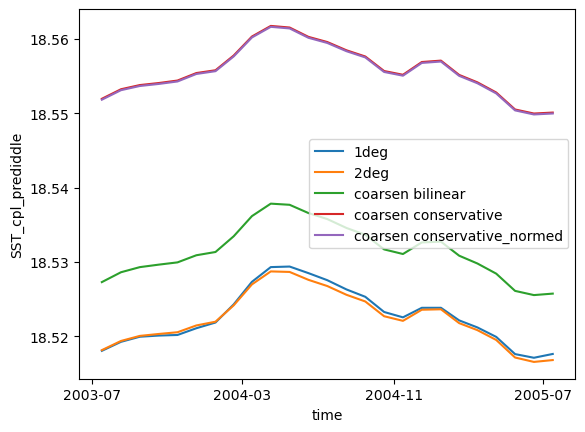

In [20]:
deg1_obs.SST_cpl_prediddle.sel(time=slice('2002', '2006')).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(label='1deg')
deg2_obs.SST_cpl_prediddle.sel(time=slice('2002', '2006')).weighted(deg2_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(label='2deg')

for method in method_list:
    deg2re_obs_dict[method].SST_cpl_prediddle.sel(time=slice('2002', '2006')).weighted(deg2_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(label='coarsen '+method)

plt.legend()

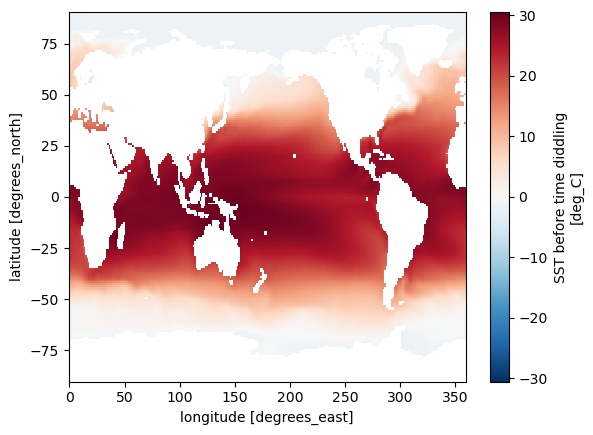

In [98]:
deg1_obs.SST_cpl_prediddle.sel(time=deg1_obs.time.dt.month == 1).sel(time=slice('1995', '2014')).mean(dim='time').plot()

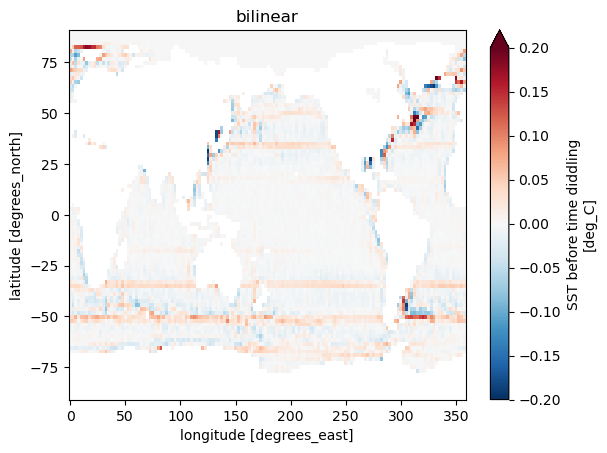

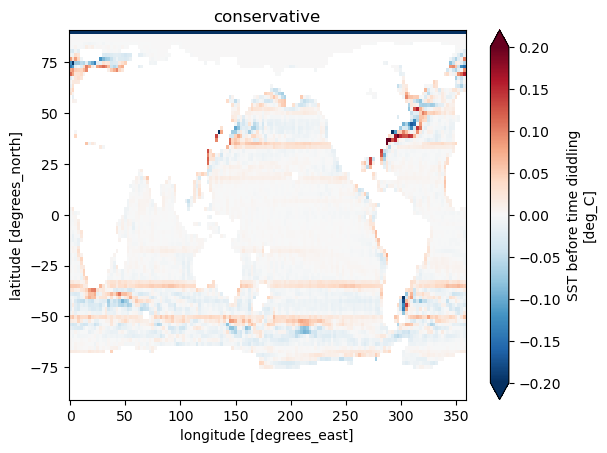

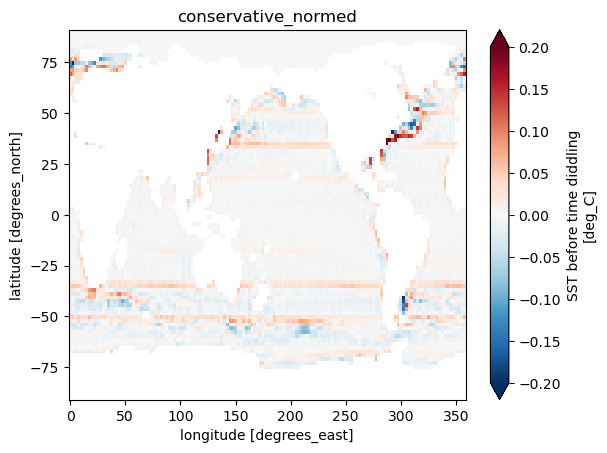

In [27]:
for method in method_list:
    plt.figure()
    (deg2_obs.SST_cpl_prediddle.sel(time=deg2_obs.time.dt.month == 1).sel(time=slice('1995', '2014')).mean(dim='time') - deg2re_obs_dict[method].SST_cpl_prediddle.sel(time=deg2_obs.time.dt.month == 1).sel(time=slice('1995', '2014')).mean(dim='time')).plot(vmin=-0.2, vmax=0.2, cmap='RdBu_r')
    plt.title(method)

In [ ]:
# xclim.close_dask_cluster(client_cluster)

# SST

## load Had SSTs

In [36]:
hadbc = xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/atm/cam/sst/sst_HadOIBl_bc_0.9x1.25_1850_2022_c241003.nc')
obs = hadbc.SST_cpl_prediddle.sel(time=slice('1980-01', '2021-12'))

In [37]:
obsm = split_years_months(obs)
obsm = obsm.chunk({'lat': 192, 'lon': 288, 'month': 1, 'year': -1}).persist()

In [38]:
tyears = obsm.year
coeffs = obsm.polyfit(dim='year', deg=1, skipna=True).polyfit_coefficients
trend = coeffs.sel(degree=1) # per year

obsm_dt = obsm - trend * (tyears - tyears[0])
obsm_dt_mean = obsm_dt.mean(dim='year')
obsm_dtdm = obsm_dt - obsm_dt_mean

In [39]:
# obsm = obsm.compute()
# obsm_dt = obsm_dt.compute()
# obsm_dtdm = obsm_dtdm.compute()

# obsm = obsm.persist()
# obsm_dt = obsm_dt.persist()
# obsm_dtdm = obsm_dtdm.persist()

Text(0, 0.5, 'SST anomaly [deg_C]')

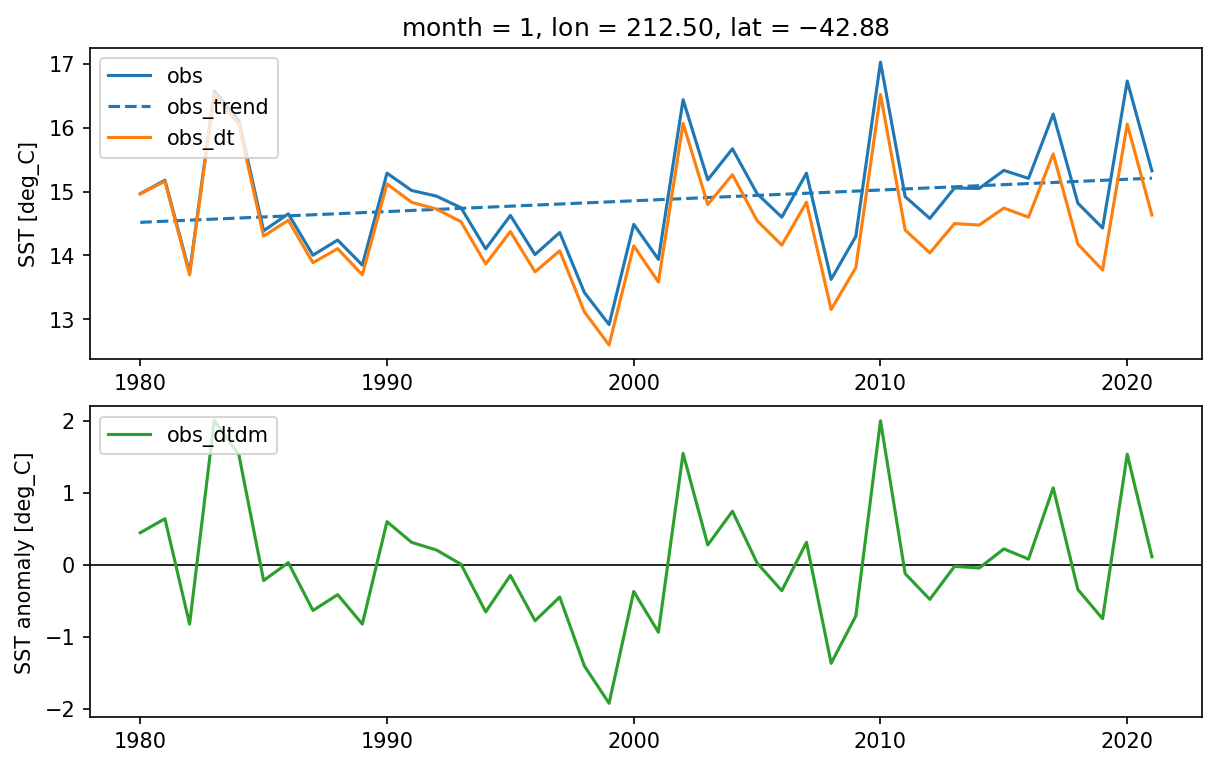

In [40]:
im = 0
ilat = 50
ilon = 170

lintrend = coeffs.sel(degree=1).isel(month=im, lat=ilat, lon=ilon) * tyears + coeffs.sel(degree=0).isel(month=im, lat=ilat, lon=ilon)

fig, ax = plt.subplots(2, 1, figsize=(8, 5), dpi=150, layout='constrained')
obsm.isel(month=im, lat=ilat, lon=ilon).plot(ax=ax[0], label='obs')
ax[0].plot(tyears, lintrend, c='tab:blue', ls='--', label='obs_trend')
obsm_dt.isel(month=im, lat=ilat, lon=ilon).plot(ax=ax[0], label='obs_dt')
ax[1].axhline(0, lw=0.8, c='k')
obsm_dtdm.isel(month=im, lat=ilat, lon=ilon).plot(ax=ax[1], c='tab:green', label='obs_dtdm')

ax[0].set_title(f'month = {im+1}, lon = ${obsm.lon.isel(lon=ilon):0.2f}$, lat = ${obsm.lat.isel(lat=ilat):0.2f}$')
ax[1].set_title('')

for a in ax:
    a.legend(loc='upper left')
    a.set_xlabel('')

ax[0].set_ylabel('SST [deg_C]')
ax[1].set_ylabel('SST anomaly [deg_C]')

## load LENS2 and compute ensemble mean (no need to run again)

In [ ]:
from glob import glob

xr.set_options(use_new_combine_kwarg_defaults=True)

v   = 'SST'
bb  = 'cmip6'
lens_dir = '/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1'
lens_starts = [
    '1001', '1021', '1041', '1061', '1081', '1101', '1121',
    '1141', '1161', '1181', '1231', '1251', '1281', '1301'
]

def load_member(yr: str, mem_str: str) -> xr.DataArray:
    """Open, time-concat, reindex, and mask one ensemble member."""
    files = sorted(
        glob(f'{lens_dir}/{v}/b.e21.BHIST{bb}.f09_g17.LE2-{yr}.{mem_str}.cam.h0.{v}.*.nc') +
        glob(f'{lens_dir}/{v}/b.e21.BSSP370{bb}.f09_g17.LE2-{yr}.{mem_str}.cam.h0.{v}.*.nc')
    )
    ds = xr.open_mfdataset(
        files,
        parallel=True,
        combine='by_coords',
        data_vars='minimal',
        coords='minimal',
        compat='override',
    )
    return (
        xclim.time_coord.shift_time(ds)
        .sel(time=tperiod)[v]
        .where(om)
    )

members = []
for im, yr in enumerate(lens_starts):
    print(f'- {yr}')
    if int(yr) < 1200:
        members.append(load_member(yr, str(im + 1).zfill(3)))
    else:
        for i in range(1, 11):
            print(str(i).zfill(3), end=' ')
            members.append(load_member(yr, str(i).zfill(3)))
        print()

lens = (
    xr.concat(members, dim='ens')
    .assign_coords(ens=np.arange(1, 51))
    .assign_attrs(units='deg_C')
    - 273.15
)
lens = lens.chunk({'time': -1}).persist()

 - 1001
 - 1021
 - 1041
 - 1061
 - 1081
 - 1101
 - 1121
 - 1141
 - 1161
 - 1181
 - 1231
001 002 003 004 005 006 007 008 009 010 
 - 1251
001 002 003 004 005 006 007 008 009 010 
 - 1281
001 002 003 004 005 006 007 008 009 010 
 - 1301
001 002 003 004 005 006 007 008 009 010 


In [ ]:
lensm_ens = lens.mean(dim='ens').chunk(time=1)
lensm_ens.to_netcdf('/glade/campaign/univ/uwas0155/ppe/future/sst/b.e21.cmip6.f09_g17.LE2-ens-mean.cam.h0.SST.nc')

## open LENS2 ensemble mean

In [56]:
# missing values = -273.15
# .where(lens.isel(time=0) != -273.15)
lens = xr.open_dataset('/glade/campaign/univ/uwas0155/ppe/future/sst/b.e21.cmip6.f09_g17.LE2-ens-mean.cam.h0.SST.nc').SST.sel(time=slice('1980-01', '2100-12'))

In [57]:
lensm = split_years_months(lens)
lensm = lensm.chunk({'lat': -1, 'lon': -1, 'year': 152, 'month': 1}).persist()

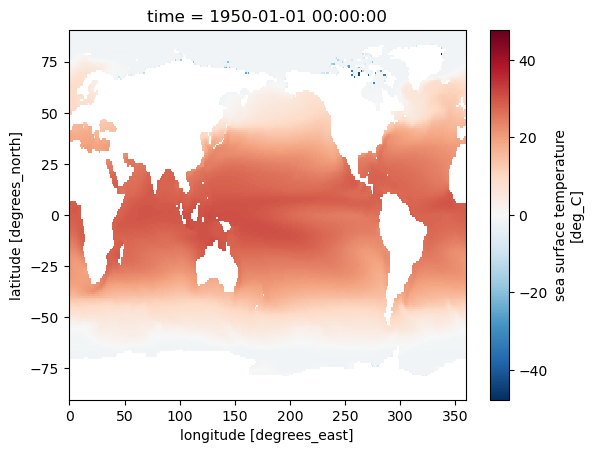

In [43]:
lens.isel(time=0).where(lens.isel(time=0) != -273.15).plot()

## compute terms

In [58]:
base_tperiod = [2007, 2021]

In [59]:
obsm_base = obsm.sel(year=slice(base_tperiod[0], base_tperiod[1])).mean(dim='year')
lensm_base = lensm.sel(year=slice(base_tperiod[0], base_tperiod[1])).mean(dim='year')

In [60]:
offset = obsm_base - lensm_base
lensm_offset = lensm + offset

In [61]:
obs_yrs = len(obsm_dtdm.year)
ens_yrs = len(lensm.year)

n_stack = ens_yrs // obs_yrs + 1

obsm_dtdm_stack = xr.concat(n_stack * [obsm_dtdm], dim='year').isel(year=slice(0, ens_yrs)).assign_coords(year=lensm.year)
assert lensm.shape == obsm_dtdm_stack.shape

In [62]:
sstm = lensm + offset + obsm_dtdm_stack

In [63]:
offset = offset.compute()
lensm_offset = lensm_offset.compute()
sstm = sstm.compute()

In [64]:
lens_offset = combine_years_months(lensm_offset.assign_coords(datetime=lensm.datetime))
sst = combine_years_months(sstm.assign_coords(datetime=lensm.datetime))

In [65]:
base_tperiod_list = [
    [2007, 2021],
    [1995, 2014],
]

sst_list = []
sstm_list = []
lens_offset_list = []
lensm_offset_list = []
for tperiod in base_tperiod_list:

    obsm_base = obsm.sel(year=slice(tperiod[0], tperiod[1])).mean(dim='year')
    lensm_base = lensm.sel(year=slice(tperiod[0], tperiod[1])).mean(dim='year')

    offset = obsm_base - lensm_base
    lensm_offset = lensm + offset

    obs_yrs = len(obsm_dtdm.year)
    ens_yrs = len(lensm.year)

    n_stack = ens_yrs // obs_yrs + 1

    obsm_dtdm_stack = xr.concat(n_stack * [obsm_dtdm], dim='year').isel(year=slice(0, ens_yrs)).assign_coords(year=lensm.year)
    assert lensm.shape == obsm_dtdm_stack.shape

    sstm = lensm + offset + obsm_dtdm_stack

    lens_offset_list.append(combine_years_months(lensm_offset.assign_coords(datetime=lensm.datetime)))
    sst_list.append(combine_years_months(sstm.assign_coords(datetime=lensm.datetime)))

    lensm_offset_list.append(lensm_offset)
    sstm_list.append(sstm)

Text(0.5, 1.0, 'month = 2, lon = $118.75$, lat = $-42.88$')

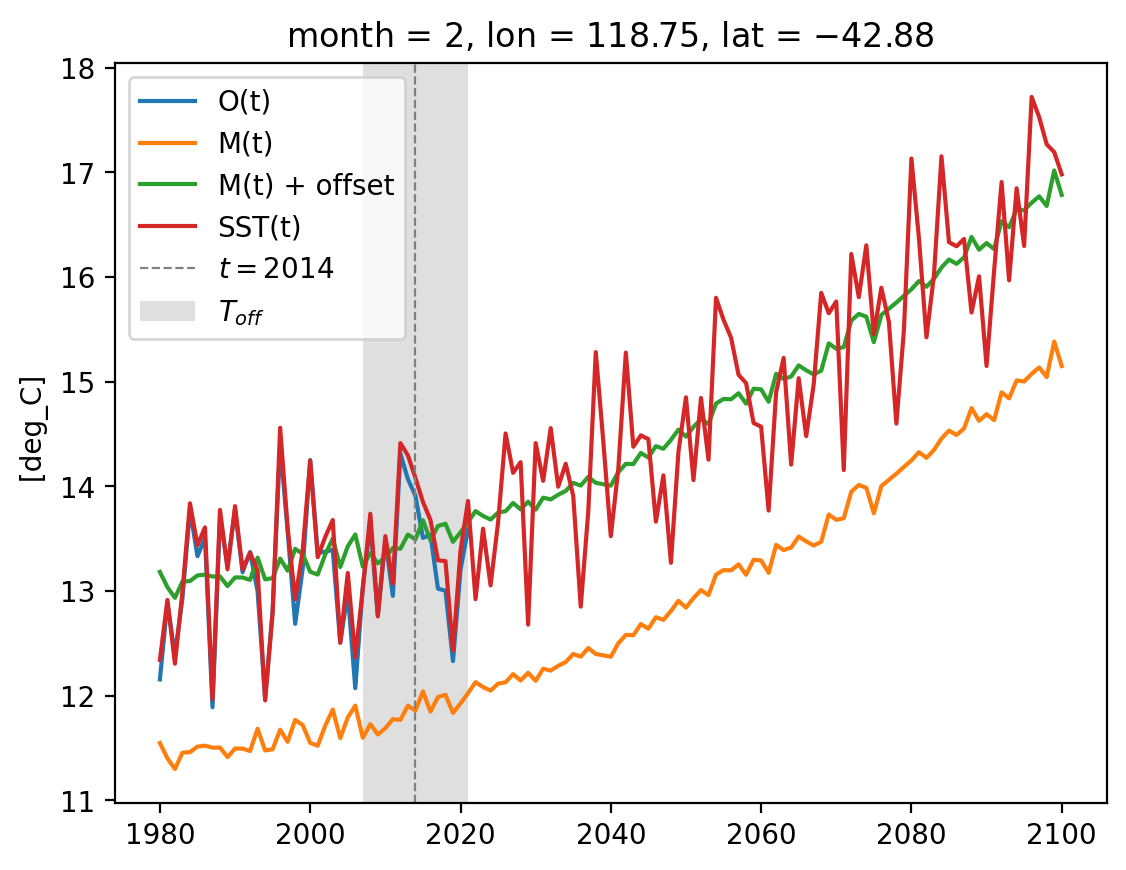

In [66]:
im = 1
ilon = 95
ilat = 50

plt.figure(dpi=200)

obsm.isel(lon=ilon, lat=ilat, month=im).plot(ls='-', label='O(t)')
lensm.isel(lon=ilon, lat=ilat, month=im).plot(ls='-', label='M(t)')
lensm_offset_list[1].isel(lon=ilon, lat=ilat, month=im).plot(ls='-', label='M(t) + offset')
sstm_list[1].isel(lon=ilon, lat=ilat, month=im).plot(ls='-', label='SST(t)')

plt.axvline(2014, color='gray', lw=0.8, ls='--', label='$t=2014$')
plt.axvspan(base_tperiod[0], base_tperiod[1], color='gray', alpha=0.25, lw=0, label='$T_{off}$')
plt.xlabel('')
plt.legend()
plt.title(f'month = {im+1}, lon = ${obsm.lon.isel(lon=ilon):0.2f}$, lat = ${obsm.lat.isel(lat=ilat):0.2f}$')

## plot terms

Text(0.5, 1.0, 'month = 2, lon = $118.75$, lat = $-42.88$')

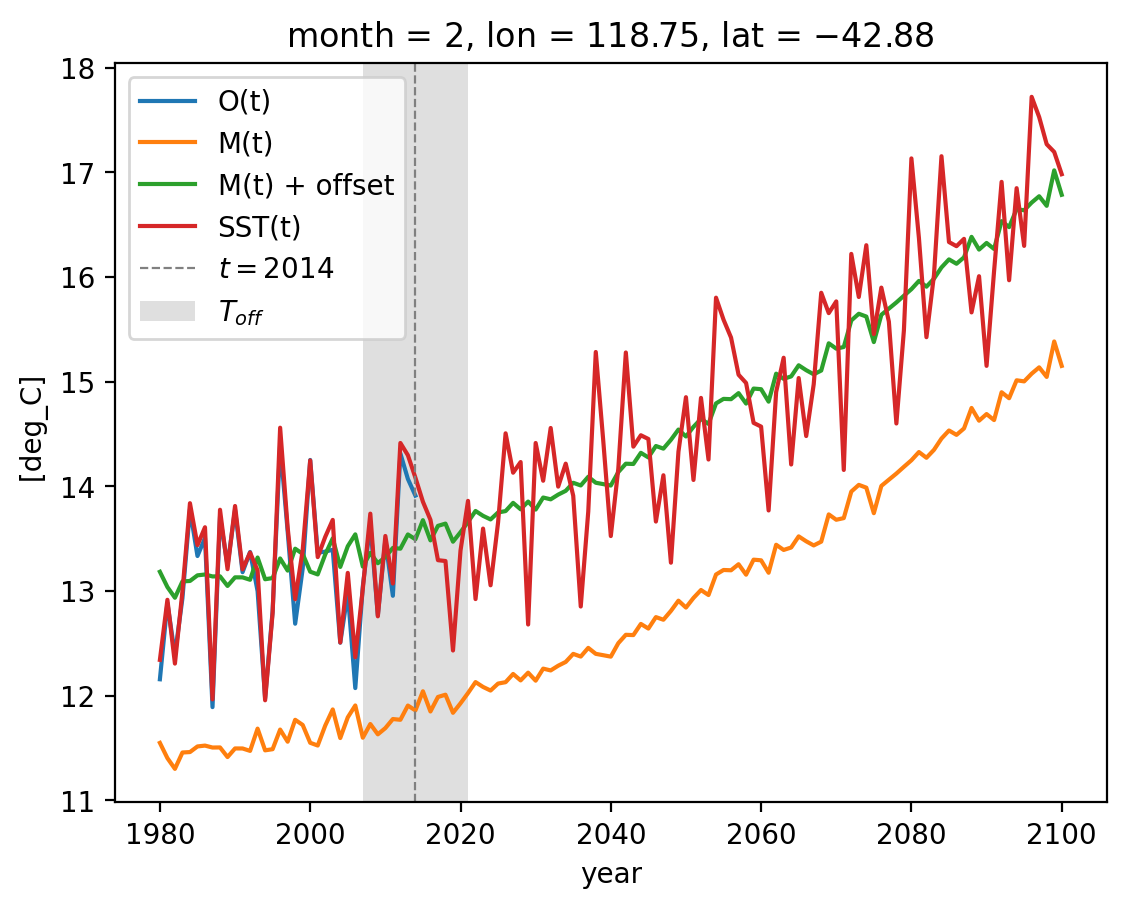

In [67]:
im = 1
ilon = 95
ilat = 50

plt.figure(dpi=200)
obsm.isel(lon=ilon, lat=ilat, month=im).sel(year=slice(None, 2014)).plot(ls='-', label='O(t)')
lensm.isel(lon=ilon, lat=ilat, month=im).plot(ls='-', label='M(t)')
lensm_offset.isel(lon=ilon, lat=ilat, month=im).plot(ls='-', label='M(t) + offset')
sstm.isel(lon=ilon, lat=ilat, month=im).plot(ls='-', label='SST(t)')

plt.axvline(2014, color='gray', lw=0.8, ls='--', label='$t=2014$')
plt.axvspan(base_tperiod[0], base_tperiod[1], color='gray', alpha=0.25, lw=0, label='$T_{off}$')

plt.legend()
plt.title(f'month = {im+1}, lon = ${obsm.lon.isel(lon=ilon):0.2f}$, lat = ${obsm.lat.isel(lat=ilat):0.2f}$')

In [68]:
# ( (lens_offset.sel(time=slice('2011-01', '2020-12')).mean(dim='time') - lens.sel(time=slice('2011-01', '2020-12')).mean(dim='time')) - (lens_offset.sel(time=slice('2091-01', '2100-12')).mean(dim='time') - lens.sel(time=slice('2091-01', '2100-12')).mean(dim='time')) ).where(lens.isel(time=0) != -273.15).plot()

Text(0.5, 1.0, 'month = 2, lon = $118.75$, lat = $-42.88$')

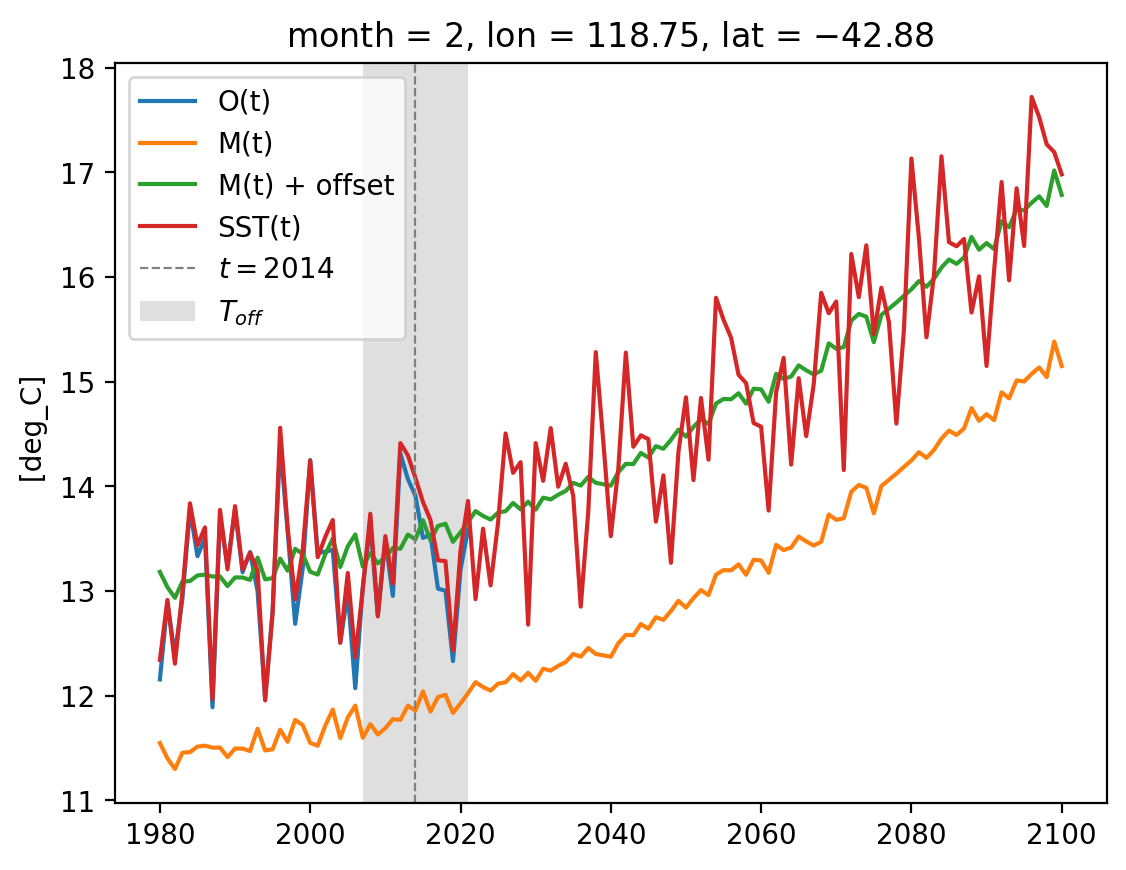

In [69]:
im = 1
ilon = 95
ilat = 50

plt.figure(dpi=200)

obsm.isel(lon=ilon, lat=ilat, month=im).plot(ls='-', label='O(t)')
lensm.isel(lon=ilon, lat=ilat, month=im).plot(ls='-', label='M(t)')
lensm_offset.isel(lon=ilon, lat=ilat, month=im).plot(ls='-', label='M(t) + offset')
sstm.isel(lon=ilon, lat=ilat, month=im).plot(ls='-', label='SST(t)')

plt.axvline(2014, color='gray', lw=0.8, ls='--', label='$t=2014$')
plt.axvspan(base_tperiod[0], base_tperiod[1], color='gray', alpha=0.25, lw=0, label='$T_{off}$')
plt.xlabel('')
plt.legend()
plt.title(f'month = {im+1}, lon = ${obsm.lon.isel(lon=ilon):0.2f}$, lat = ${obsm.lat.isel(lat=ilat):0.2f}$')

Text(0.5, 1.0, 'annual mean, lon = $118.75$, lat = $-42.88$')

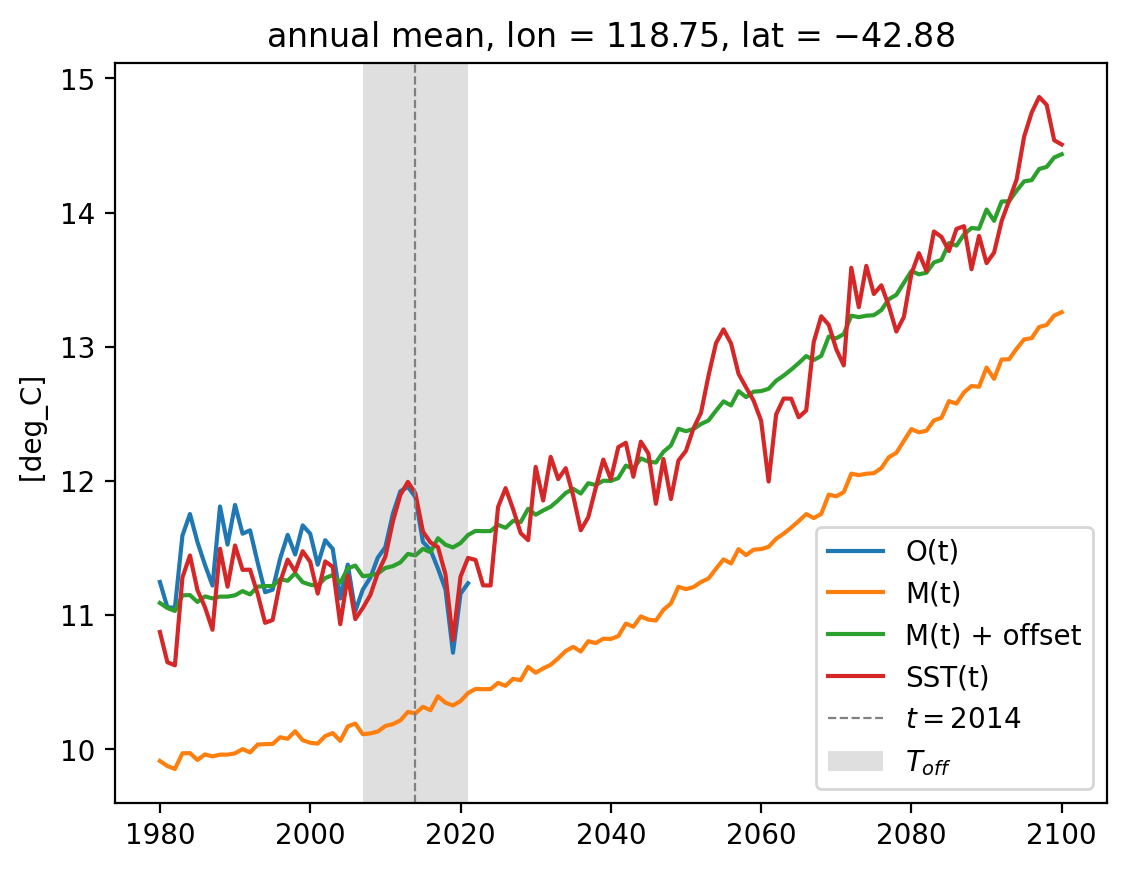

In [70]:
ilon = 95
ilat = 50

plt.figure(dpi=200)

obs.isel(lon=ilon, lat=ilat).groupby('time.year').mean().plot(ls='-', label='O(t)')
lens.isel(lon=ilon, lat=ilat).groupby('time.year').mean().plot(ls='-', label='M(t)')
lens_offset.isel(lon=ilon, lat=ilat).groupby('time.year').mean().plot(ls='-', label='M(t) + offset')
sst.isel(lon=ilon, lat=ilat).groupby('time.year').mean().plot(ls='-', label='SST(t)')

plt.axvline(2014, color='gray', lw=0.8, ls='--', label='$t=2014$')
plt.axvspan(base_tperiod[0], base_tperiod[1], color='gray', alpha=0.25, lw=0, label='$T_{off}$')

plt.xlabel('')
plt.legend()
plt.title(f'annual mean, lon = ${obsm.lon.isel(lon=ilon):0.2f}$, lat = ${obsm.lat.isel(lat=ilat):0.2f}$')

## ENSO

In [71]:
def compute_nino34_rolling_reference(sst, area, rolling_nmonths=5, to_plot=True):
    '''
    "Nino X Index computation: (a) Compute area averaged total SST from Niño X region; (b) Compute monthly climatology
    (e.g., 1950-1979) for area averaged total SST from Niño X region, and subtract climatology from area averaged total
    SST time series to obtain anomalies; (c) Smooth the anomalies with a 5-month running mean; (d) Normalize the smoothed
    values by its standard deviation over the climatological period."
    https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni#:~:text=Technical%20Notes
    '''
    sst_nino34 = sst.sel(lat=slice(-5, 5), lon=slice(190, 240))
    sst_nino34_ts = sst_nino34.weighted(area).mean(dim=['lat', 'lon'])

    sst_nino34_base_mean = (
        sst_nino34_ts
        .groupby('time.month')
        .map(lambda x: x.rolling(time=30, center=True).mean().ffill('time').bfill('time'))
    )
    sst_nino34_base_std = (
        sst_nino34_ts
        .groupby('time.month')
        .map(lambda x: x.rolling(time=30, center=True).std().ffill('time').bfill('time'))
    )

    sst_nino34_anom_mean_norm = (sst_nino34_ts - sst_nino34_base_mean) / sst_nino34_base_std

    nino34 = sst_nino34_anom_mean_norm.rolling(time=rolling_nmonths, center=True).mean()

    if to_plot:
        fig = plt.figure()

        plt.fill_between(
            nino34.time.data,
            nino34.where(nino34 >= 0.5).data,
            0.5,
            color = "red",
            alpha = 0.9,
        )
        plt.fill_between(
            nino34.time.data,
            nino34.where(nino34 <= -0.5).data,
            -0.5,
            color = "blue",
            alpha = 0.9,
        )

        nino34.plot(color="black", lw=0.8)
        plt.axhline(0, color="black", lw = 0.5)
        plt.axhline(0.5, color="black", linewidth = 0.5, linestyle="dotted") 
        plt.axhline(-0.5, color="black", linewidth = 0.5, linestyle="dotted")

        plt.title(f"NINO 3.4 Index (30-year rolling reference period)")
        plt.xlabel('Time (years)')
        plt.ylabel("SST Anomalies (°C)")

    return nino34


lens_area = xr.open_dataset('/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1/AREA/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.AREA.195001-195912.nc')
lens_area = lens_area.AREA.isel(time=0).reindex(lat=obs.lat, lon=obs.lon, method='nearest', tolerance=1e-3)

In [72]:
obs_nino34 = compute_nino34_rolling_reference(obs, lens_area)

ModuleNotFoundError: No module named 'bottleneck'

In [ ]:
obs_roll_ref = (
    obs
    .sel(lat=slice(-5, 5), lon=slice(190, 240))
    .weighted(lens_area).mean(dim=['lat', 'lon'])
    .groupby('time.month')
    .map(lambda x: x.rolling(time=30, center=True).mean().ffill('time').bfill('time'))
)

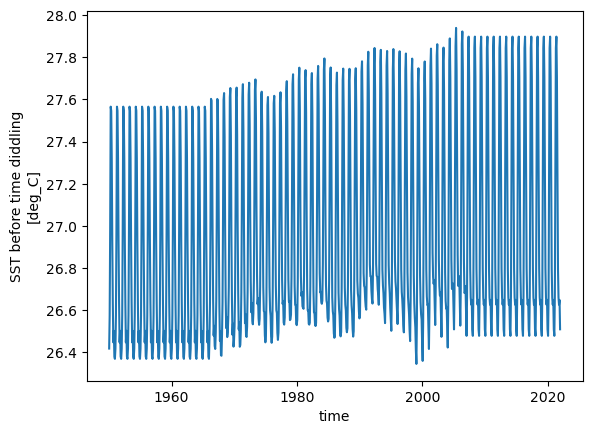

In [ ]:
obs_roll_ref.plot()

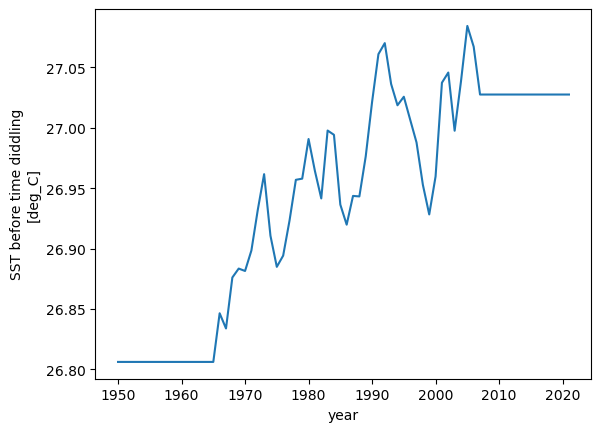

In [ ]:
obs_roll_ref.groupby('time.year').mean().plot()

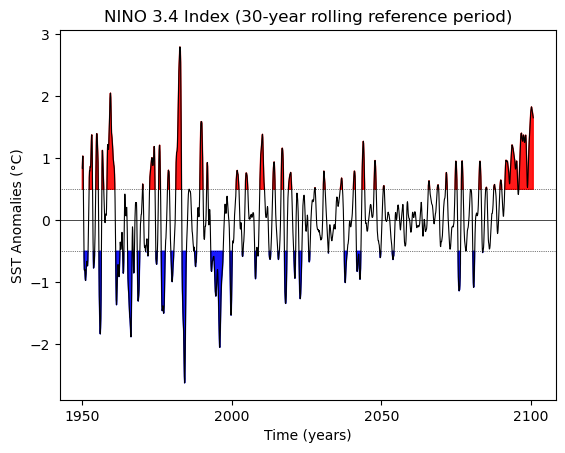

In [ ]:
lens_nino34 = compute_nino34_rolling_reference(lens, lens_area)

In [ ]:
lens_roll_ref = (
    lens
    .sel(lat=slice(-5, 5), lon=slice(190, 240))
    .weighted(lens_area).mean(dim=['lat', 'lon'])
    .groupby('time.month')
    .map(lambda x: x.rolling(time=30, center=True).mean().ffill('time').bfill('time'))
)

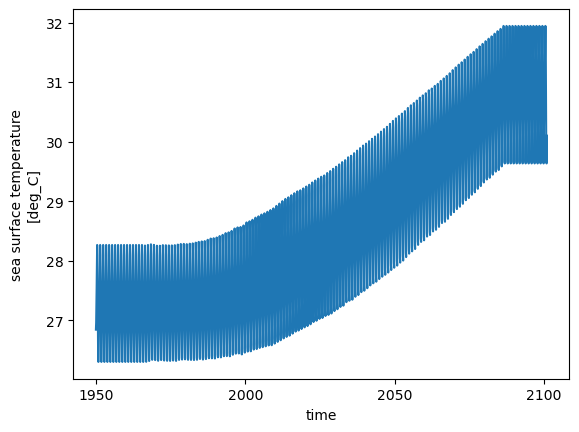

In [ ]:
lens_roll_ref.plot()

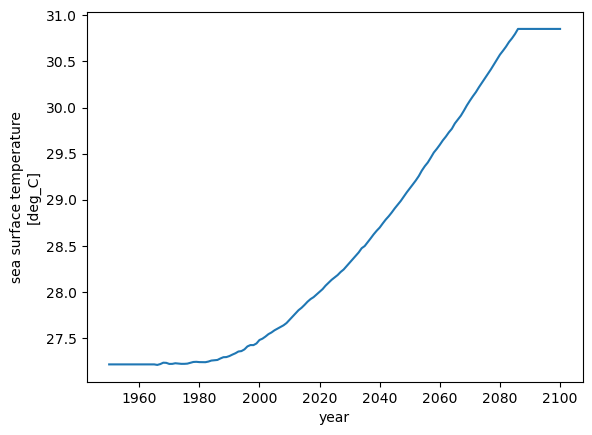

In [ ]:
lens_roll_ref.groupby('time.year').mean().plot()

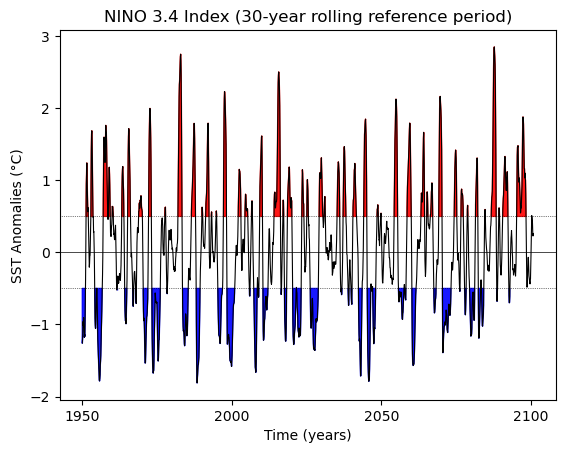

In [ ]:
sst_nino34 = compute_nino34_rolling_reference(sst, lens_area)

In [ ]:
sst_roll_ref = (
    sst
    .sel(lat=slice(-5, 5), lon=slice(190, 240))
    .weighted(lens_area).mean(dim=['lat', 'lon'])
    .groupby('time.month')
    .map(lambda x: x.rolling(time=30, center=True).mean().ffill('time').bfill('time'))
)

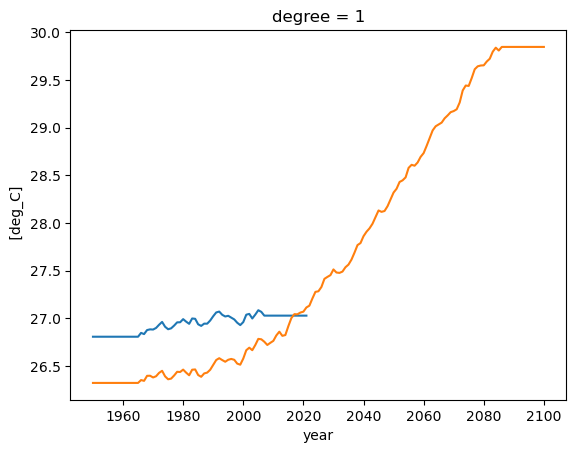

In [ ]:
obs_roll_ref.groupby('time.year').mean().plot()
sst_roll_ref.groupby('time.year').mean().plot()

Text(0.5, 0, 'Time (years)')

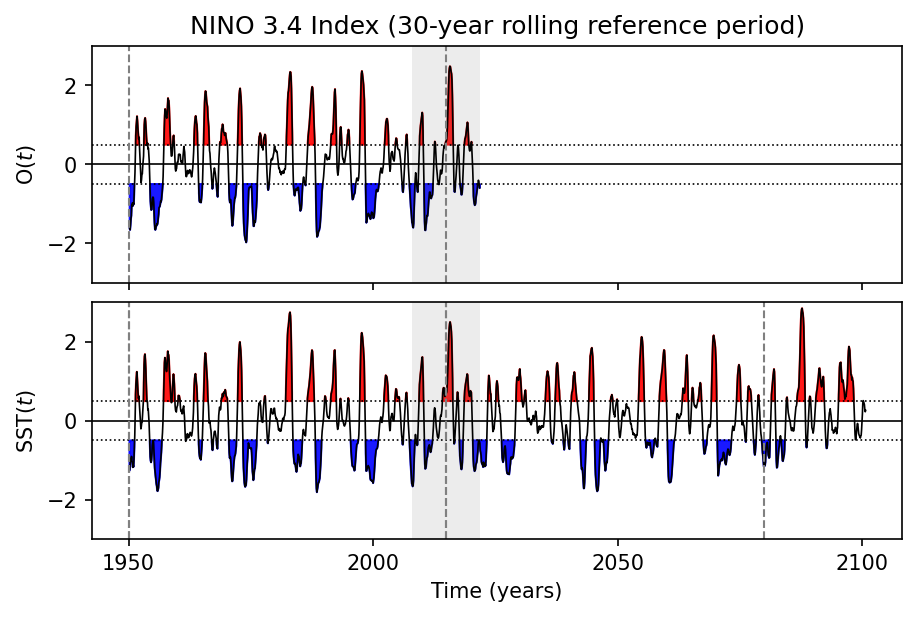

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(6, 4), sharey=True, sharex=True, layout='constrained', dpi=150)

for a, y in zip(ax, [obs_nino34, sst_nino34]):

    a.fill_between(
        y.time.data,
        y.where(y >= 0.5).data,
        0.5,
        color = "red",
        alpha = 0.9,
    )
    a.fill_between(
        y.time.data,
        y.where(y <= -0.5).data,
        -0.5,
        color = "blue",
        alpha = 0.9,
    )

    y.plot(ax=a, color="black", lw=0.8)
    a.axhline(0, color="black", lw = 0.8)
    a.axhline(0.5, color="black", linewidth = 0.8, linestyle="dotted") 
    a.axhline(-0.5, color="black", linewidth = 0.8, linestyle="dotted")
    a.axvspan(
        cftime.DatetimeGregorian(2008, 1, 1),
        cftime.DatetimeGregorian(2021, 12, 1),
        color='gray', alpha=0.15, lw=0, label='$T_{base}$'
    )

    a.axvline(cftime.DatetimeGregorian(1950, 1, 1), color='gray', lw=1, ls='--')
    a.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')

    a.set_title('')
    a.set_xlabel('')
    a.set_ylim(-3, 3)

ax[1].axvline(cftime.DatetimeGregorian(1950, 1, 1), color='gray', lw=1, ls='--')
ax[1].axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
ax[1].axvline(cftime.DatetimeGregorian(2014+65, 12, 1), color='gray', lw=1, ls='--')

ax[0].set_title(f"NINO 3.4 Index (30-year rolling reference period)")
ax[0].set_ylabel("O$(t)$")
ax[1].set_ylabel("SST$(t)$")

ax[-1].set_xlabel('Time (years)')

Text(0, 0.5, 'NINO 3.4')

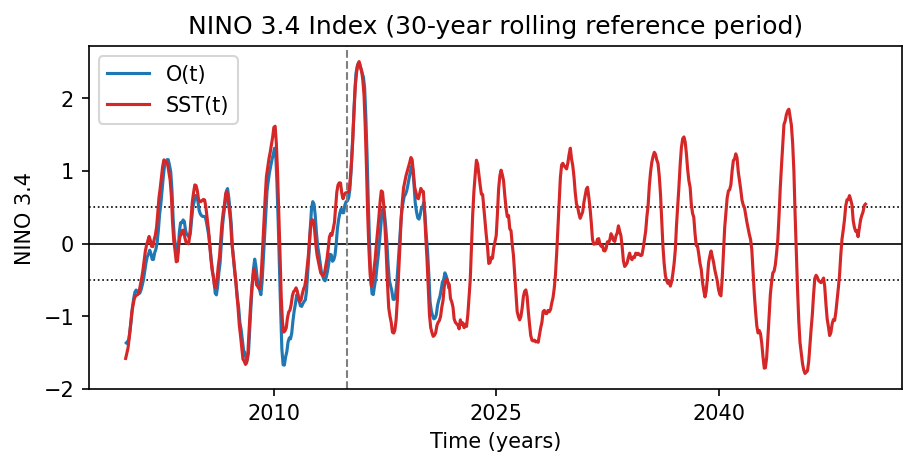

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3), layout='constrained', dpi=150)

ax.axhline(0, color="black", lw = 0.8)
ax.axhline(0.5, color="black", linewidth = 0.8, linestyle="dotted") 
ax.axhline(-0.5, color="black", linewidth = 0.8, linestyle="dotted")

obs_nino34.sel(time=slice('2000-01', '2049-12')).plot(c='tab:blue', label='O(t)')
sst_nino34.sel(time=slice('2000-01', '2049-12')).plot(c='tab:red', label='SST(t)')

ax.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')

ax.legend()
ax.set_title(f"NINO 3.4 Index (30-year rolling reference period)")
ax.set_xlabel('Time (years)')
ax.set_ylabel("NINO 3.4")

## N Atlantic patch

In [74]:
lat_bnds = [47, 57]
lon_bnds = [315, 335]

nat = obs.isel(time=0)
nat = ((nat.lat >= lat_bnds[0]) & (nat.lat < lat_bnds[1]) & (nat.lon >= lon_bnds[0]) & (nat.lon < lon_bnds[1]))
nat = nat.where(om)

Text(0, 0.5, 'SST [deg_C]')

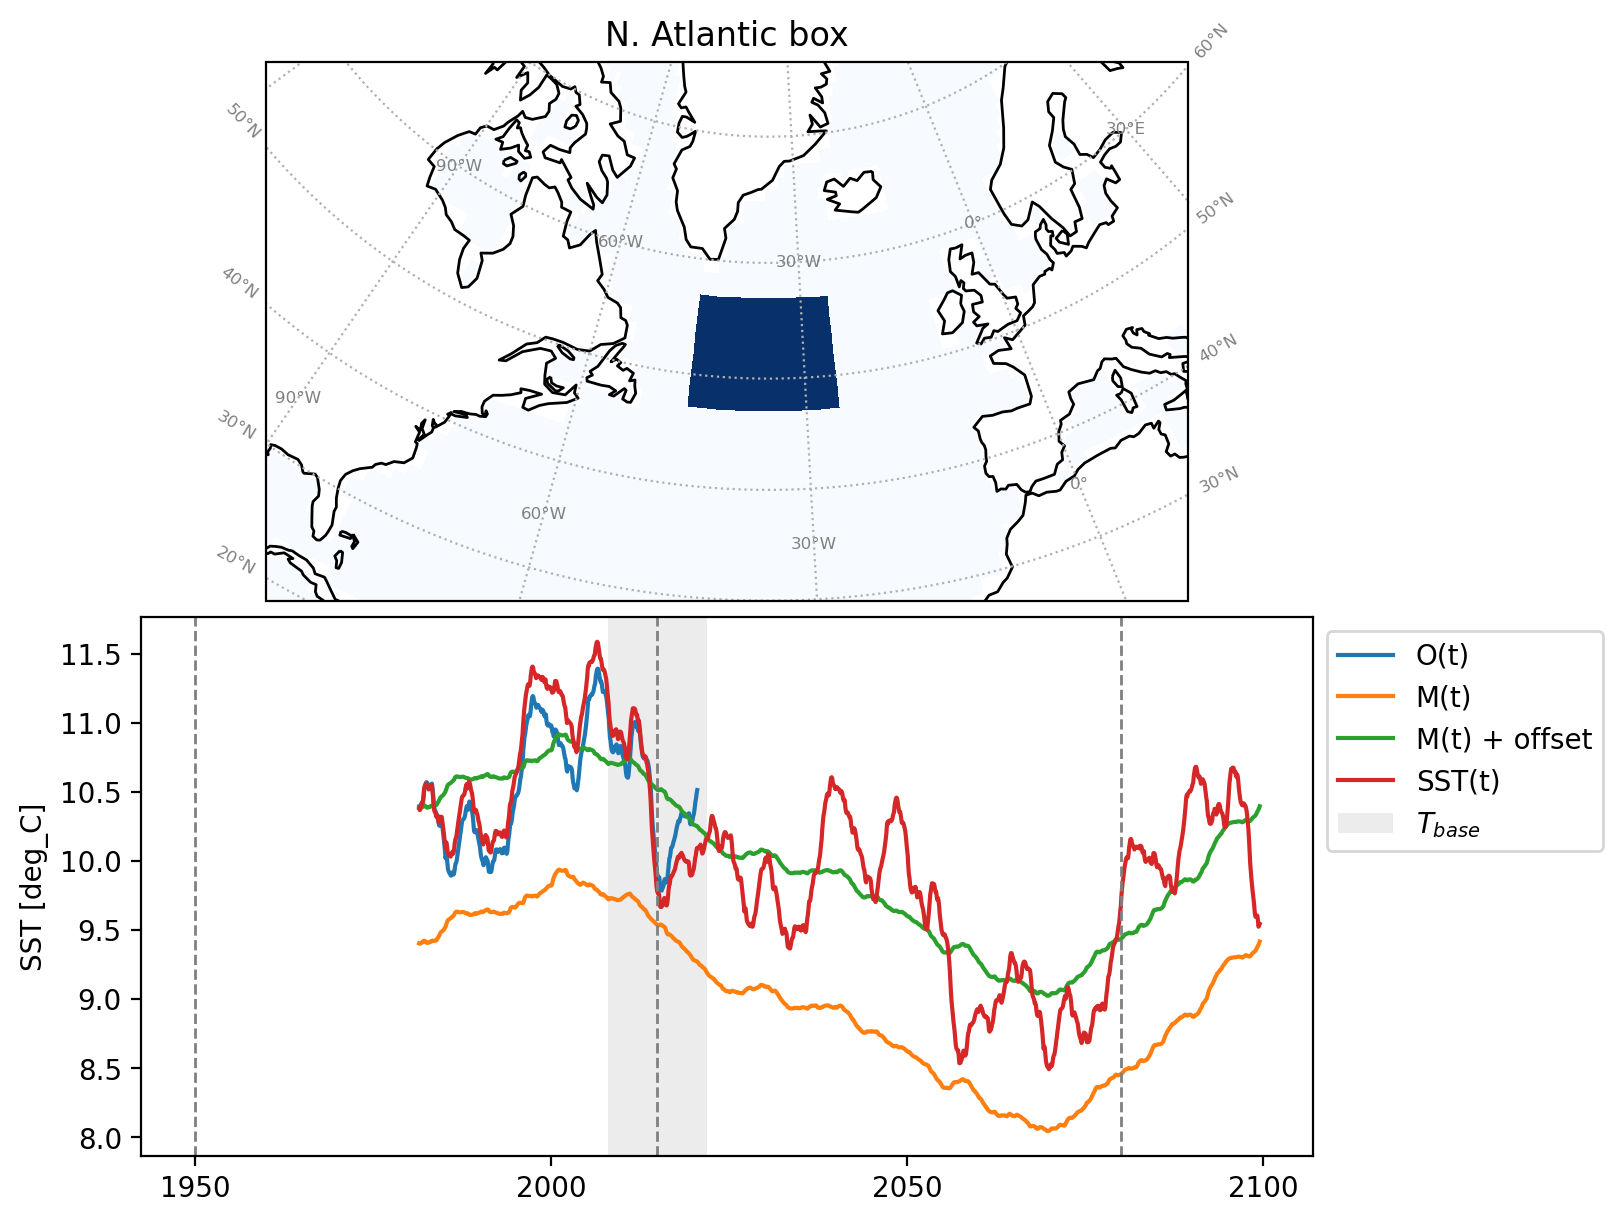

In [75]:
# fig = plt.figure(dpi=200, figsize=(12, 4))
fig = plt.figure(dpi=200, figsize=(8, 6), layout='constrained')

axm = fig.add_subplot(2, 1, 1, projection=ccrs.LambertConformal(central_longitude=-35))
axt = fig.add_subplot(2, 1, 2)

nat.plot(
    ax=axm,
    cmap='Blues',
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    # cbar_kwargs={'fraction': 0.03}
 )
axm.set_extent([-90, 10, 30, 70], crs=ccrs.PlateCarree())
axm.coastlines()
gl = axm.gridlines(lw=0.8, ls=':', draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_left = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 6, 'color': 'gray'}
gl.ylabel_style = {'size': 6, 'color': 'gray'}
axm.set_title('N. Atlantic box')

obs.where(nat).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='O(t)')
lens.where(nat).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t)')
lens_offset.where(nat).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t) + offset')
sst.where(nat).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='SST(t)')

axt.axvspan(
    cftime.DatetimeGregorian(2008, 1, 1),
    cftime.DatetimeGregorian(2021, 12, 1),
    color='gray', alpha=0.15, lw=0, label='$T_{base}$'
)
axt.axvline(cftime.DatetimeGregorian(1950, 1, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014+65, 12, 1), color='gray', lw=1, ls='--')

axt.set_xlabel('')
axt.legend(loc='upper left', bbox_to_anchor=[1, 1])
# axt.set_title(f'SST, 3-year running mean, N. Atlantic box')
axt.set_title('')
axt.set_ylabel('SST [deg_C]')

## S East Pacific patch
62°–47°S,140°–70°W

> Dong, Y., K. C. Armour, D. S. Battisti, and E. Blanchard-Wrigglesworth, 2022: Two-Way Teleconnections between the Southern Ocean and the Tropical Pacific via a Dynamic Feedback. J. Climate, 35, 6267–6282, https://doi.org/10.1175/JCLI-D-22-0080.1.

In [76]:
lat_bnds = [-62, -47]
lon_bnds = [220, 290]

sep = obs.isel(time=0)
sep = ((sep.lat >= lat_bnds[0]) & (sep.lat < lat_bnds[1]) & (sep.lon >= lon_bnds[0]) & (sep.lon < lon_bnds[1]))
sep = sep.where(om)

Text(0, 0.5, 'SST [deg_C]')

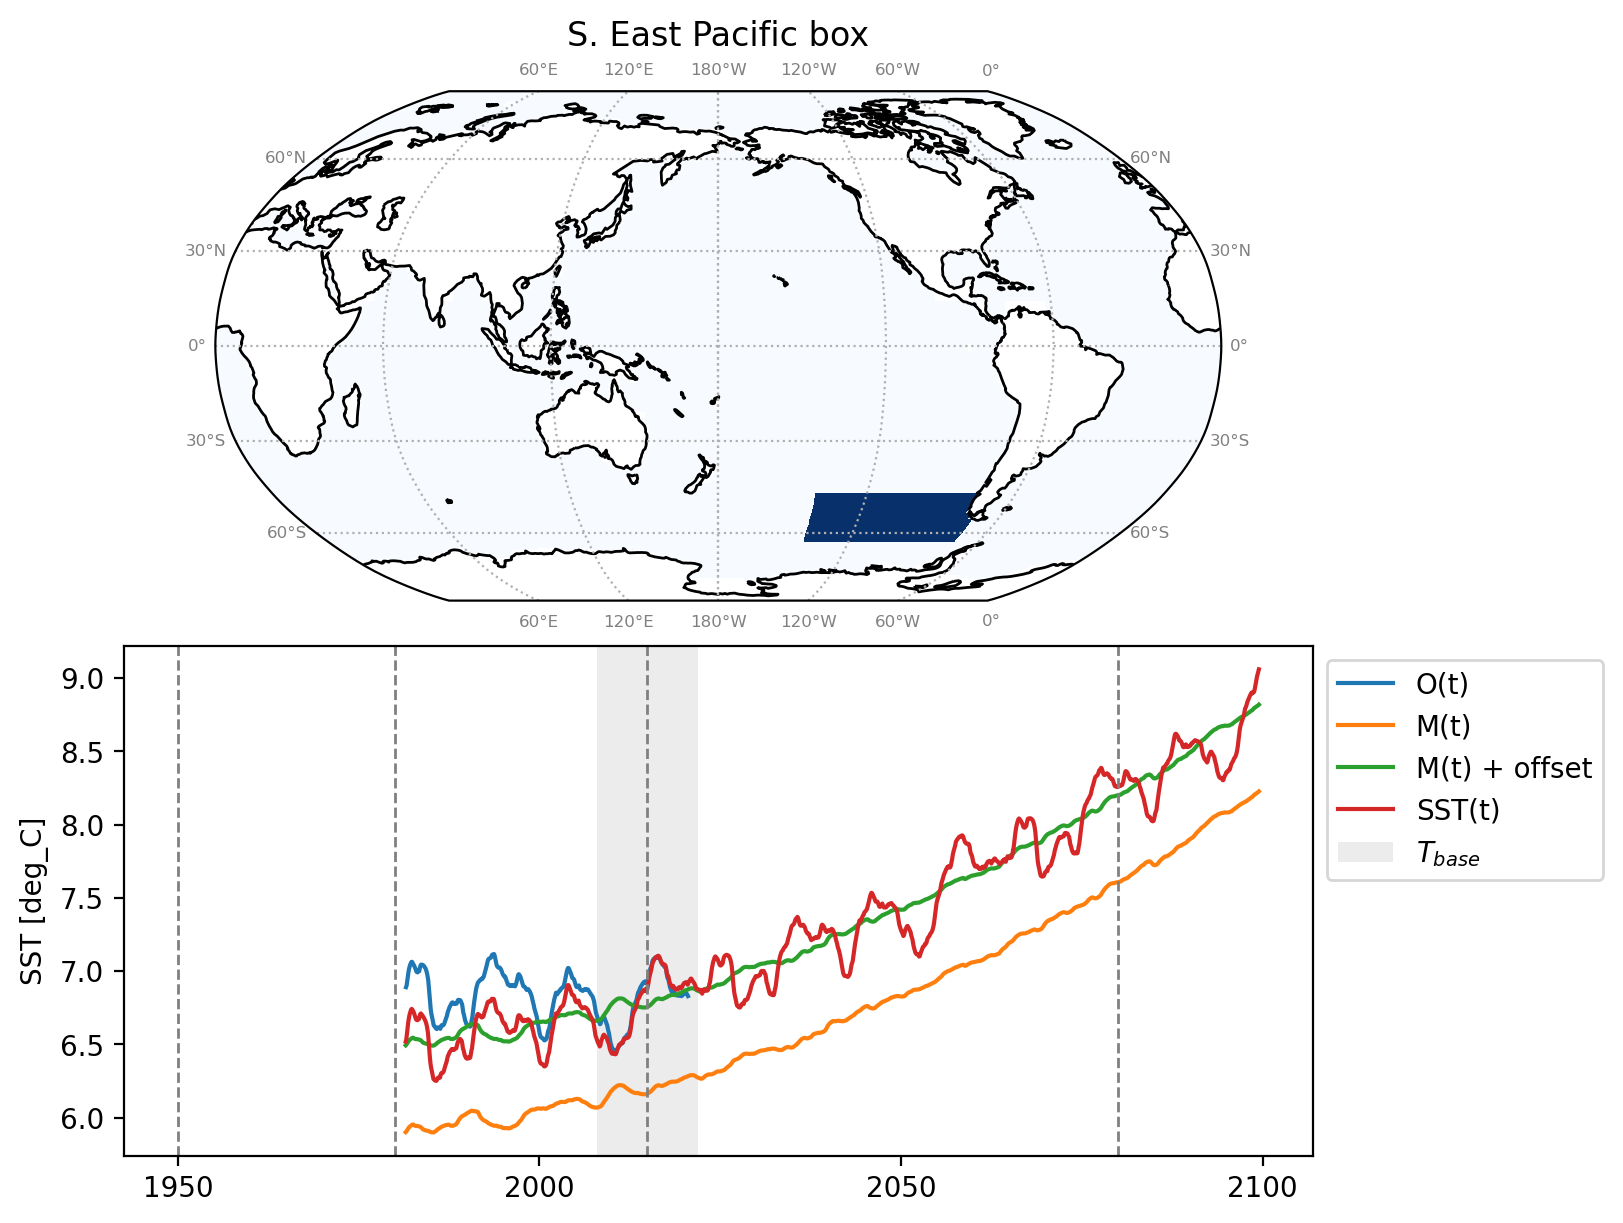

In [77]:
fig = plt.figure(dpi=200, figsize=(8, 6), layout='constrained')

axm = fig.add_subplot(2, 1, 1, projection=ccrs.Robinson(central_longitude=-180))
axt = fig.add_subplot(2, 1, 2)

sep.plot(
    ax=axm,
    cmap='Blues',
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    # cbar_kwargs={'fraction': 0.03}
 )
# axm.set_extent([-178, 178, -90, 90], crs=ccrs.PlateCarree())
axm.coastlines()
gl = axm.gridlines(lw=0.8, ls=':', draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_left = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 6, 'color': 'gray'}
gl.ylabel_style = {'size': 6, 'color': 'gray'}
axm.set_title('S. East Pacific box')

obs.where(sep).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='O(t)')
lens.where(sep).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t)')
lens_offset.where(sep).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t) + offset')
sst.where(sep).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='SST(t)')

axt.axvspan(
    cftime.DatetimeGregorian(2008, 1, 1),
    cftime.DatetimeGregorian(2021, 12, 1),
    color='gray', alpha=0.15, lw=0, label='$T_{base}$'
)
axt.axvline(cftime.DatetimeGregorian(1950, 1, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(1980, 1, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014+65, 12, 1), color='gray', lw=1, ls='--')

axt.set_xlabel('')
axt.legend(loc='upper left', bbox_to_anchor=[1, 1])
# axt.set_title(f'SST, 3-year running mean, S. East Pacific box')
axt.set_title('')
axt.set_ylabel('SST [deg_C]')

## N East Pacific patch

In [78]:
lat_bnds = [35, 50]
lon_bnds = [190, 220]

nep = obs.isel(time=0)
nep = ((nep.lat >= lat_bnds[0]) & (nep.lat < lat_bnds[1]) & (nep.lon >= lon_bnds[0]) & (nep.lon < lon_bnds[1]))
nep = nep.where(om)

Text(0, 0.5, 'SST [deg_C]')

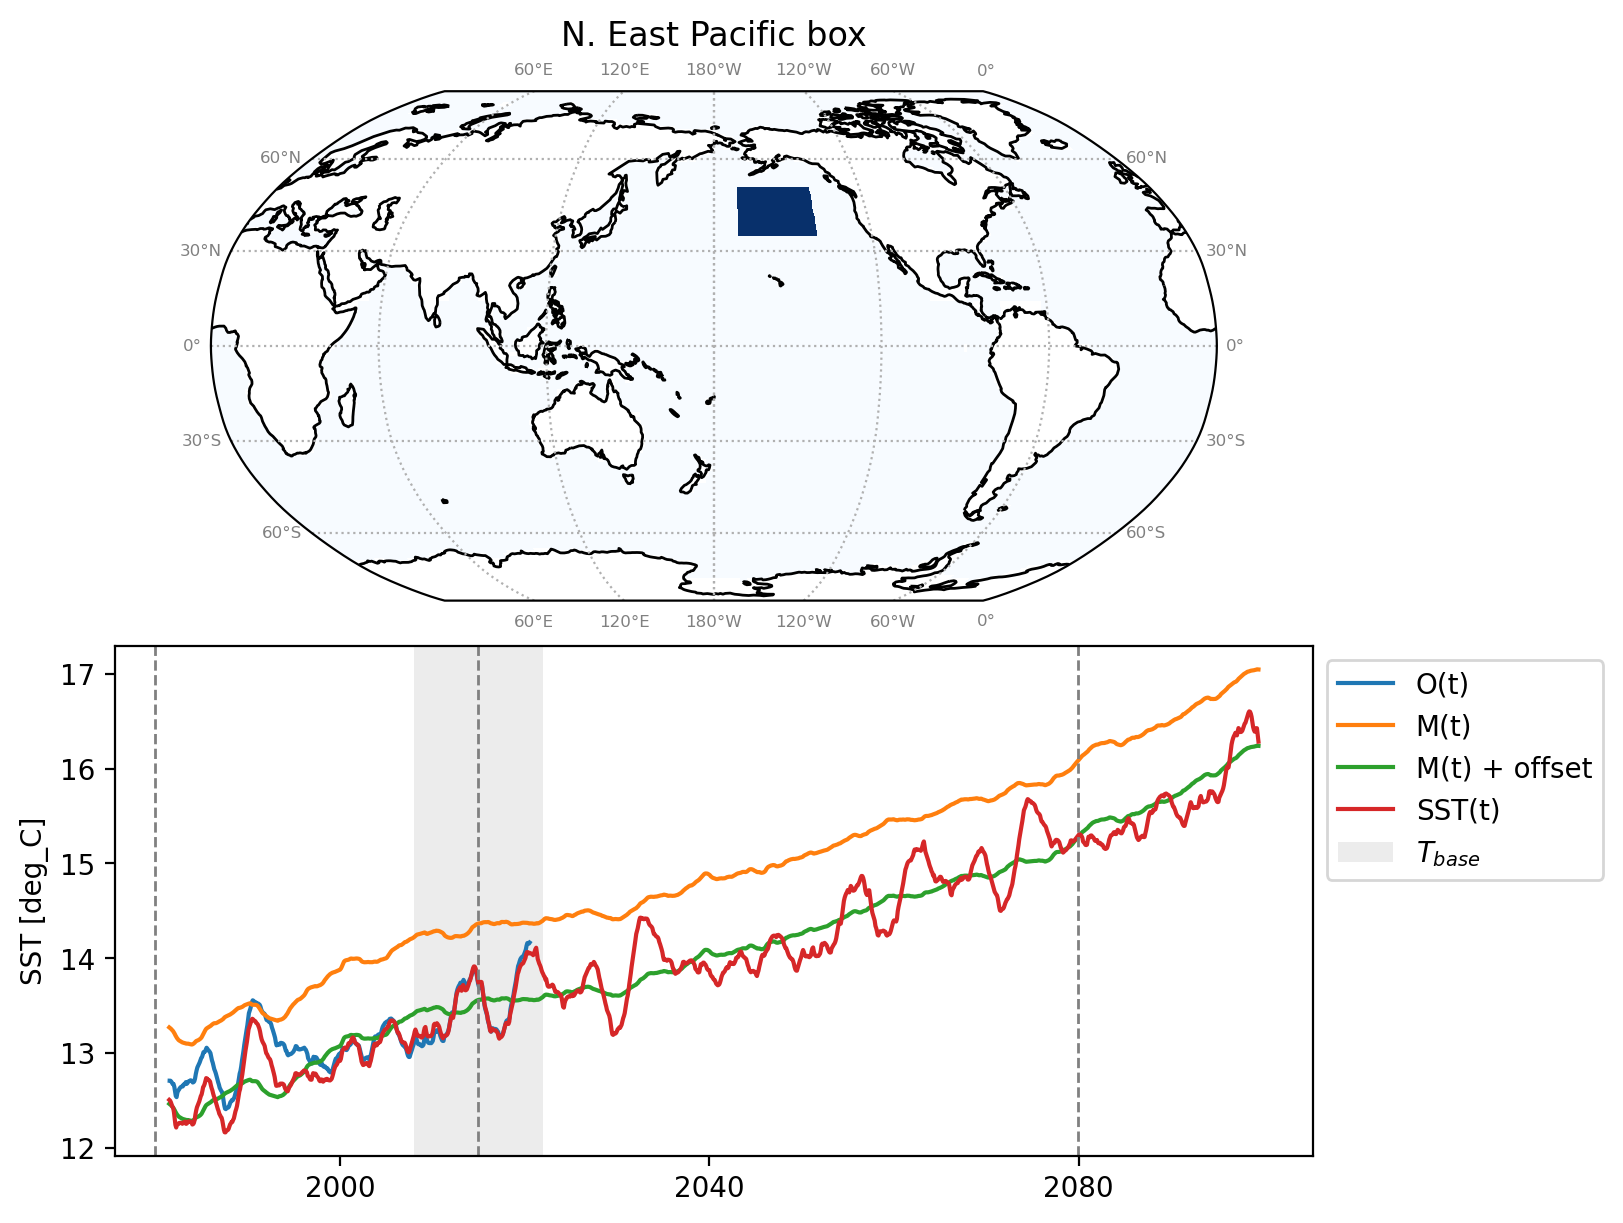

In [81]:
fig = plt.figure(dpi=200, figsize=(8, 6), layout='constrained')

axm = fig.add_subplot(2, 1, 1, projection=ccrs.Robinson(central_longitude=-180))
axt = fig.add_subplot(2, 1, 2)

nep.plot(
    ax=axm,
    cmap='Blues',
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    # cbar_kwargs={'fraction': 0.03}
 )
# axm.set_extent([-178, 178, -90, 90], crs=ccrs.PlateCarree())
axm.coastlines()
gl = axm.gridlines(lw=0.8, ls=':', draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_left = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 6, 'color': 'gray'}
gl.ylabel_style = {'size': 6, 'color': 'gray'}
axm.set_title('N. East Pacific box')

obs.where(nep).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='O(t)')
lens.where(nep).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t)')
lens_offset.where(nep).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t) + offset')
sst.where(nep).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='SST(t)')

axt.axvspan(
    cftime.DatetimeGregorian(2008, 1, 1),
    cftime.DatetimeGregorian(2021, 12, 1),
    color='gray', alpha=0.15, lw=0, label='$T_{base}$'
)
# axt.axvline(cftime.DatetimeGregorian(1950, 1, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(1980, 1, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014+65, 12, 1), color='gray', lw=1, ls='--')

axt.set_xlabel('')
axt.legend(loc='upper left', bbox_to_anchor=[1, 1])
# axt.set_title(f'SST, 3-year running mean, N. East Pacific box')
axt.set_title('')
axt.set_ylabel('SST [deg_C]')

## N Pacific patch

In [146]:
lat_bnds = [30, 50]
lon_bnds = [150, 230]

npa = obs.isel(time=0)
npa = ((npa.lat >= lat_bnds[0]) & (npa.lat < lat_bnds[1]) & (npa.lon >= lon_bnds[0]) & (npa.lon < lon_bnds[1]))
npa = npa.where(om)

Text(0, 0.5, 'SST [deg_C]')

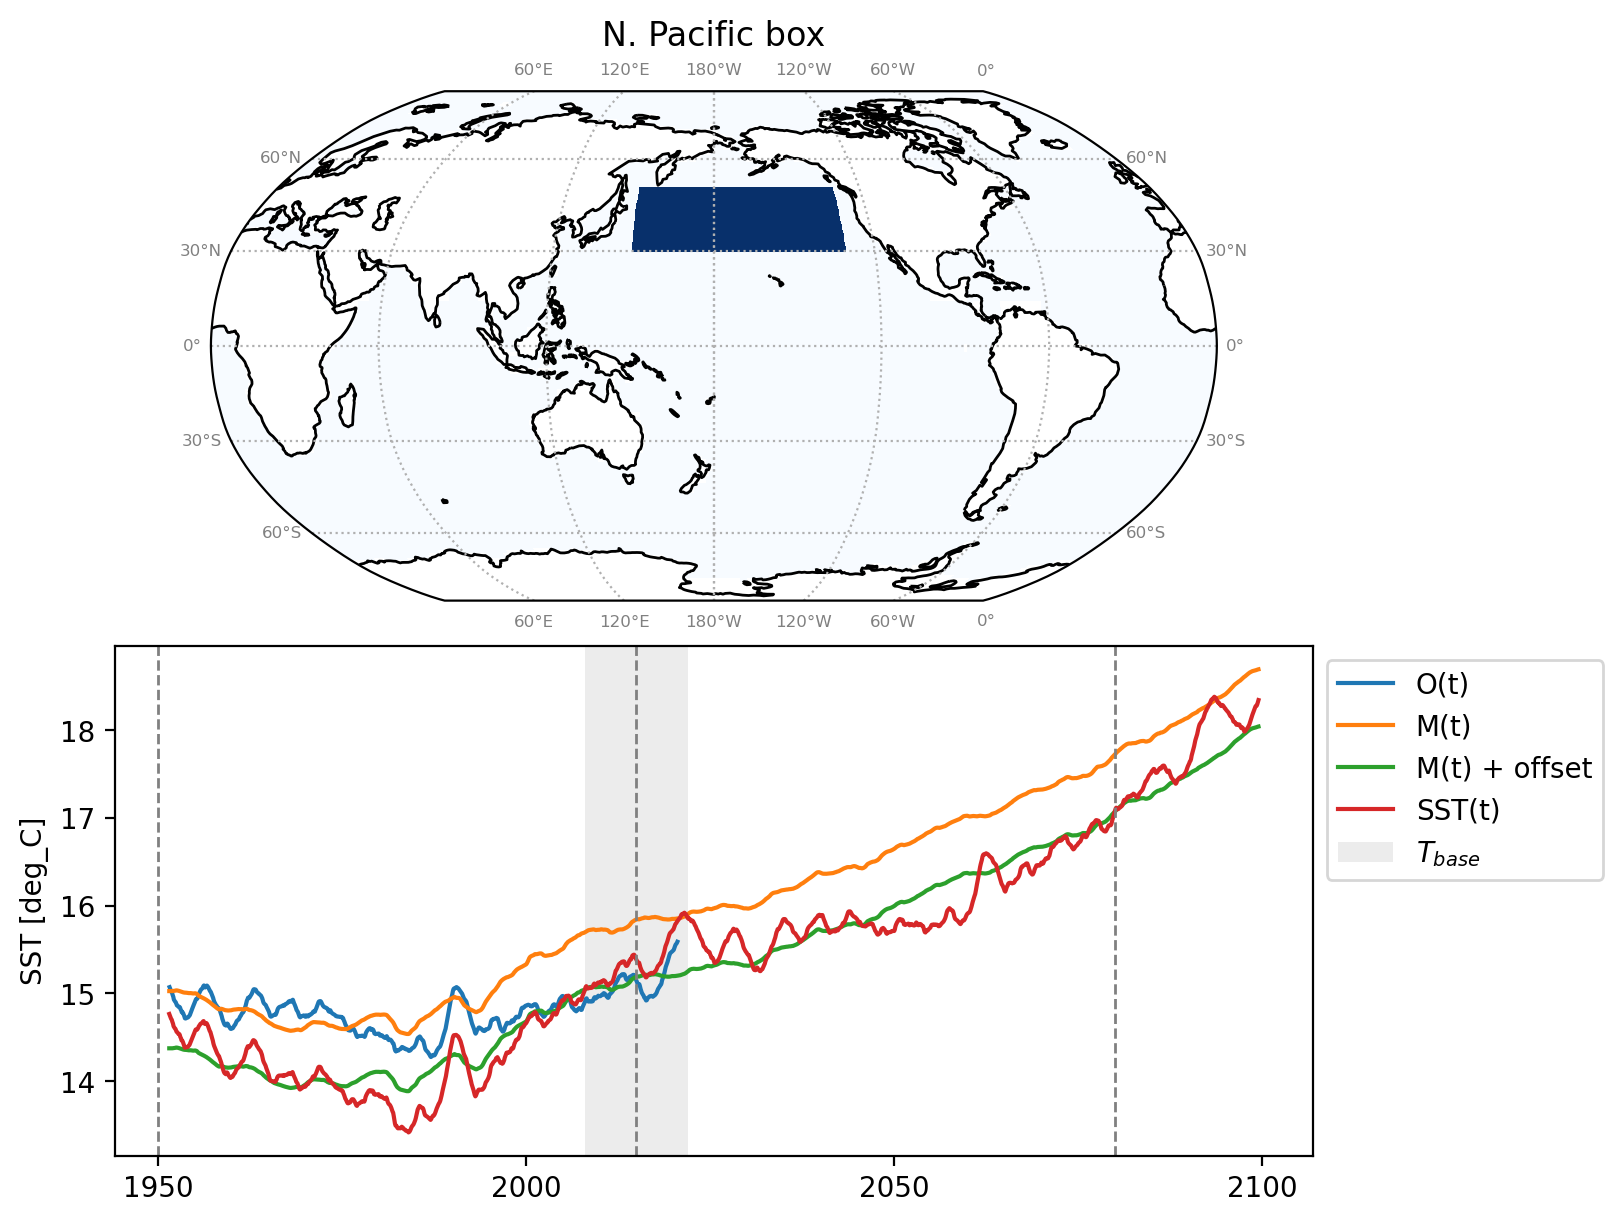

In [147]:
fig = plt.figure(dpi=200, figsize=(8, 6), layout='constrained')

axm = fig.add_subplot(2, 1, 1, projection=ccrs.Robinson(central_longitude=-180))
axt = fig.add_subplot(2, 1, 2)

npa.plot(
    ax=axm,
    cmap='Blues',
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    # cbar_kwargs={'fraction': 0.03}
 )
# axm.set_extent([-178, 178, -90, 90], crs=ccrs.PlateCarree())
axm.coastlines()
gl = axm.gridlines(lw=0.8, ls=':', draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_left = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 6, 'color': 'gray'}
gl.ylabel_style = {'size': 6, 'color': 'gray'}
axm.set_title('N. Pacific box')

obs.where(npa).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='O(t)')
lens.where(npa).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t)')
lens_offset.where(npa).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t) + offset')
sst.where(npa).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='SST(t)')

axt.axvspan(
    cftime.DatetimeGregorian(2008, 1, 1),
    cftime.DatetimeGregorian(2021, 12, 1),
    color='gray', alpha=0.15, lw=0, label='$T_{base}$'
)
axt.axvline(cftime.DatetimeGregorian(1950, 1, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014+65, 12, 1), color='gray', lw=1, ls='--')

axt.set_xlabel('')
axt.legend(loc='upper left', bbox_to_anchor=[1, 1])
# axt.set_title(f'SST, 3-year running mean, N. East Pacific box')
axt.set_title('')
axt.set_ylabel('SST [deg_C]')

## Indian Ocean box

In [139]:
lat_bnds = [-15, 5]
lon_bnds = [60, 90]

ind = obs.isel(time=0)
ind = ((ind.lat >= lat_bnds[0]) & (ind.lat < lat_bnds[1]) & (ind.lon >= lon_bnds[0]) & (ind.lon < lon_bnds[1]))
ind = ind.where(om)

Text(0, 0.5, 'SST [deg_C]')

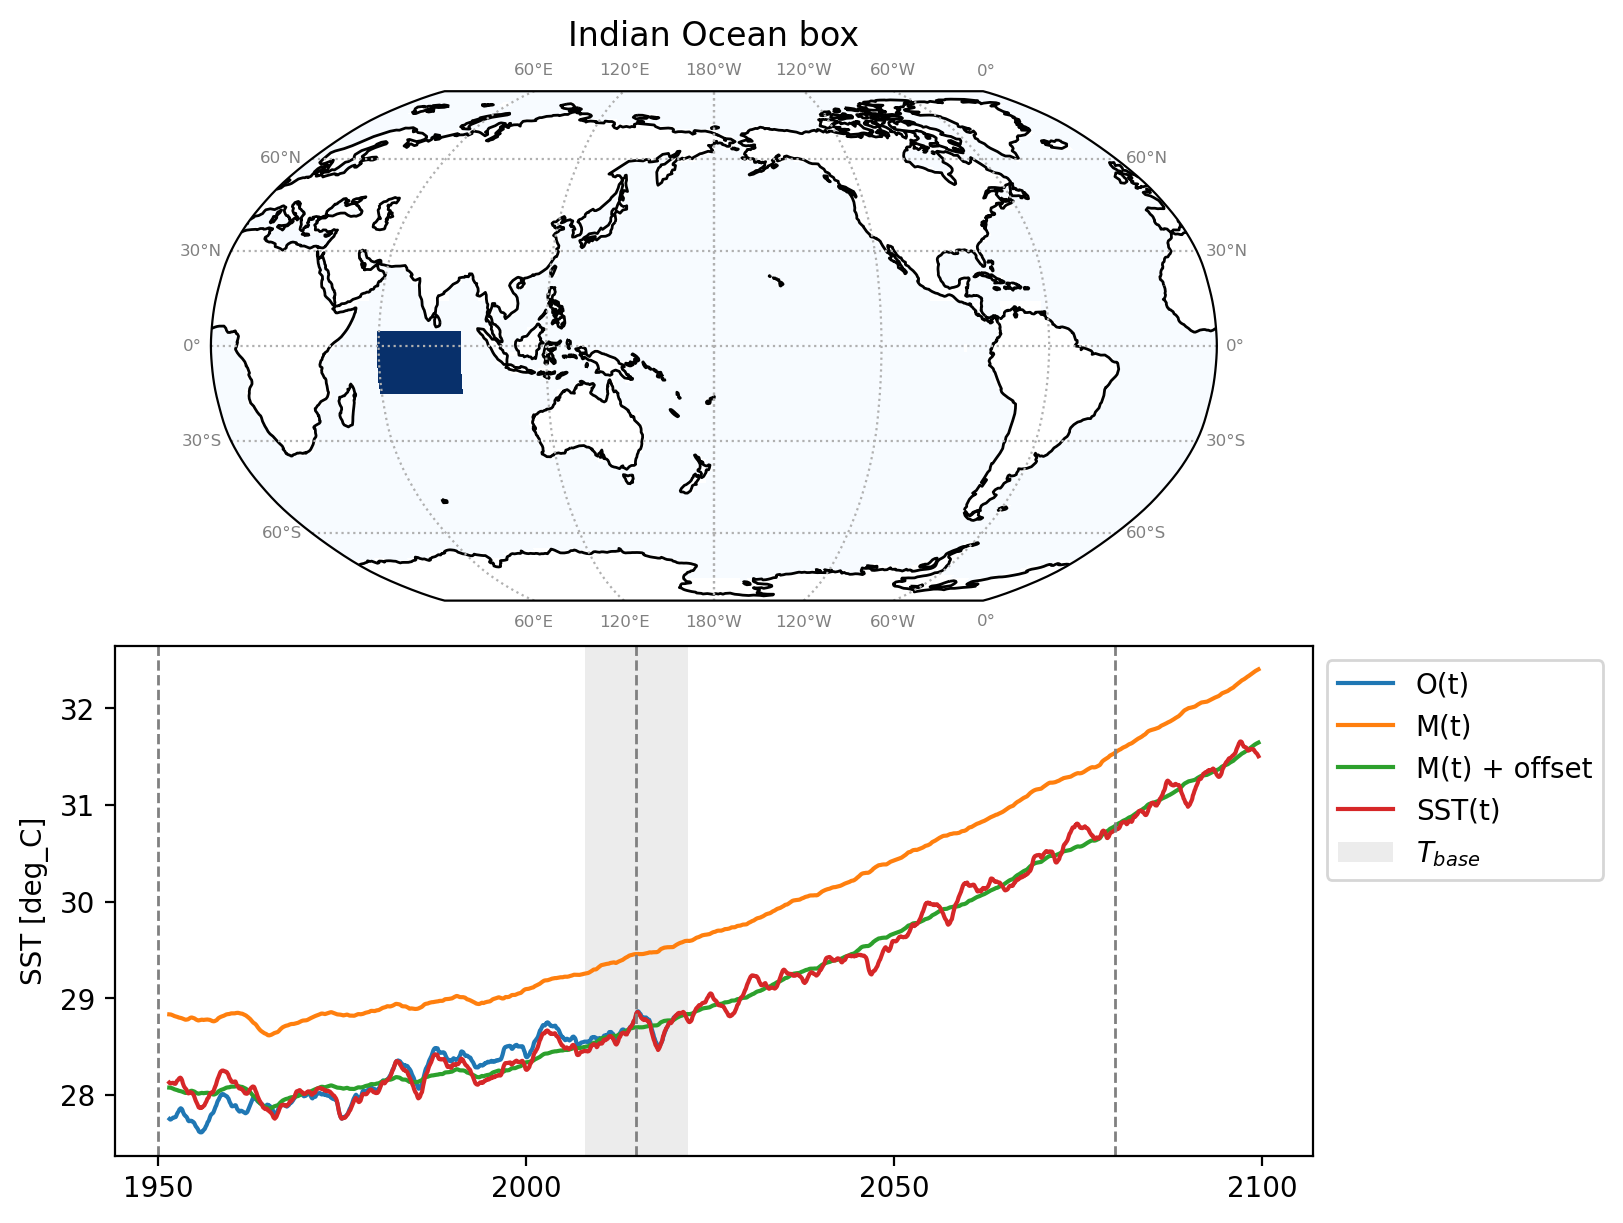

In [140]:
fig = plt.figure(dpi=200, figsize=(8, 6), layout='constrained')

axm = fig.add_subplot(2, 1, 1, projection=ccrs.Robinson(central_longitude=-180))
axt = fig.add_subplot(2, 1, 2)

ind.plot(
    ax=axm,
    cmap='Blues',
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    # cbar_kwargs={'fraction': 0.03}
 )
# axm.set_extent([-178, 178, -90, 90], crs=ccrs.PlateCarree())
axm.coastlines()
gl = axm.gridlines(lw=0.8, ls=':', draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_left = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 6, 'color': 'gray'}
gl.ylabel_style = {'size': 6, 'color': 'gray'}
axm.set_title('Indian Ocean box')

obs.where(ind).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='O(t)')
lens.where(ind).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t)')
lens_offset.where(ind).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t) + offset')
sst.where(ind).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='SST(t)')

axt.axvspan(
    cftime.DatetimeGregorian(2008, 1, 1),
    cftime.DatetimeGregorian(2021, 12, 1),
    color='gray', alpha=0.15, lw=0, label='$T_{base}$'
)
axt.axvline(cftime.DatetimeGregorian(1950, 1, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014+65, 12, 1), color='gray', lw=1, ls='--')

axt.set_xlabel('')
axt.legend(loc='upper left', bbox_to_anchor=[1, 1])
axt.set_title('')
axt.set_ylabel('SST [deg_C]')

## Southern Ocean small patch

In [ ]:
lat_bnds = [-62, -47]
lon_bnds = [100, 140]

sop = obs.isel(time=0)
sop = ((sop.lat >= lat_bnds[0]) & (sop.lat < lat_bnds[1]) & (sop.lon >= lon_bnds[0]) & (sop.lon < lon_bnds[1]))
sop = sop.where(om)

Text(0, 0.5, 'SST [deg_C]')

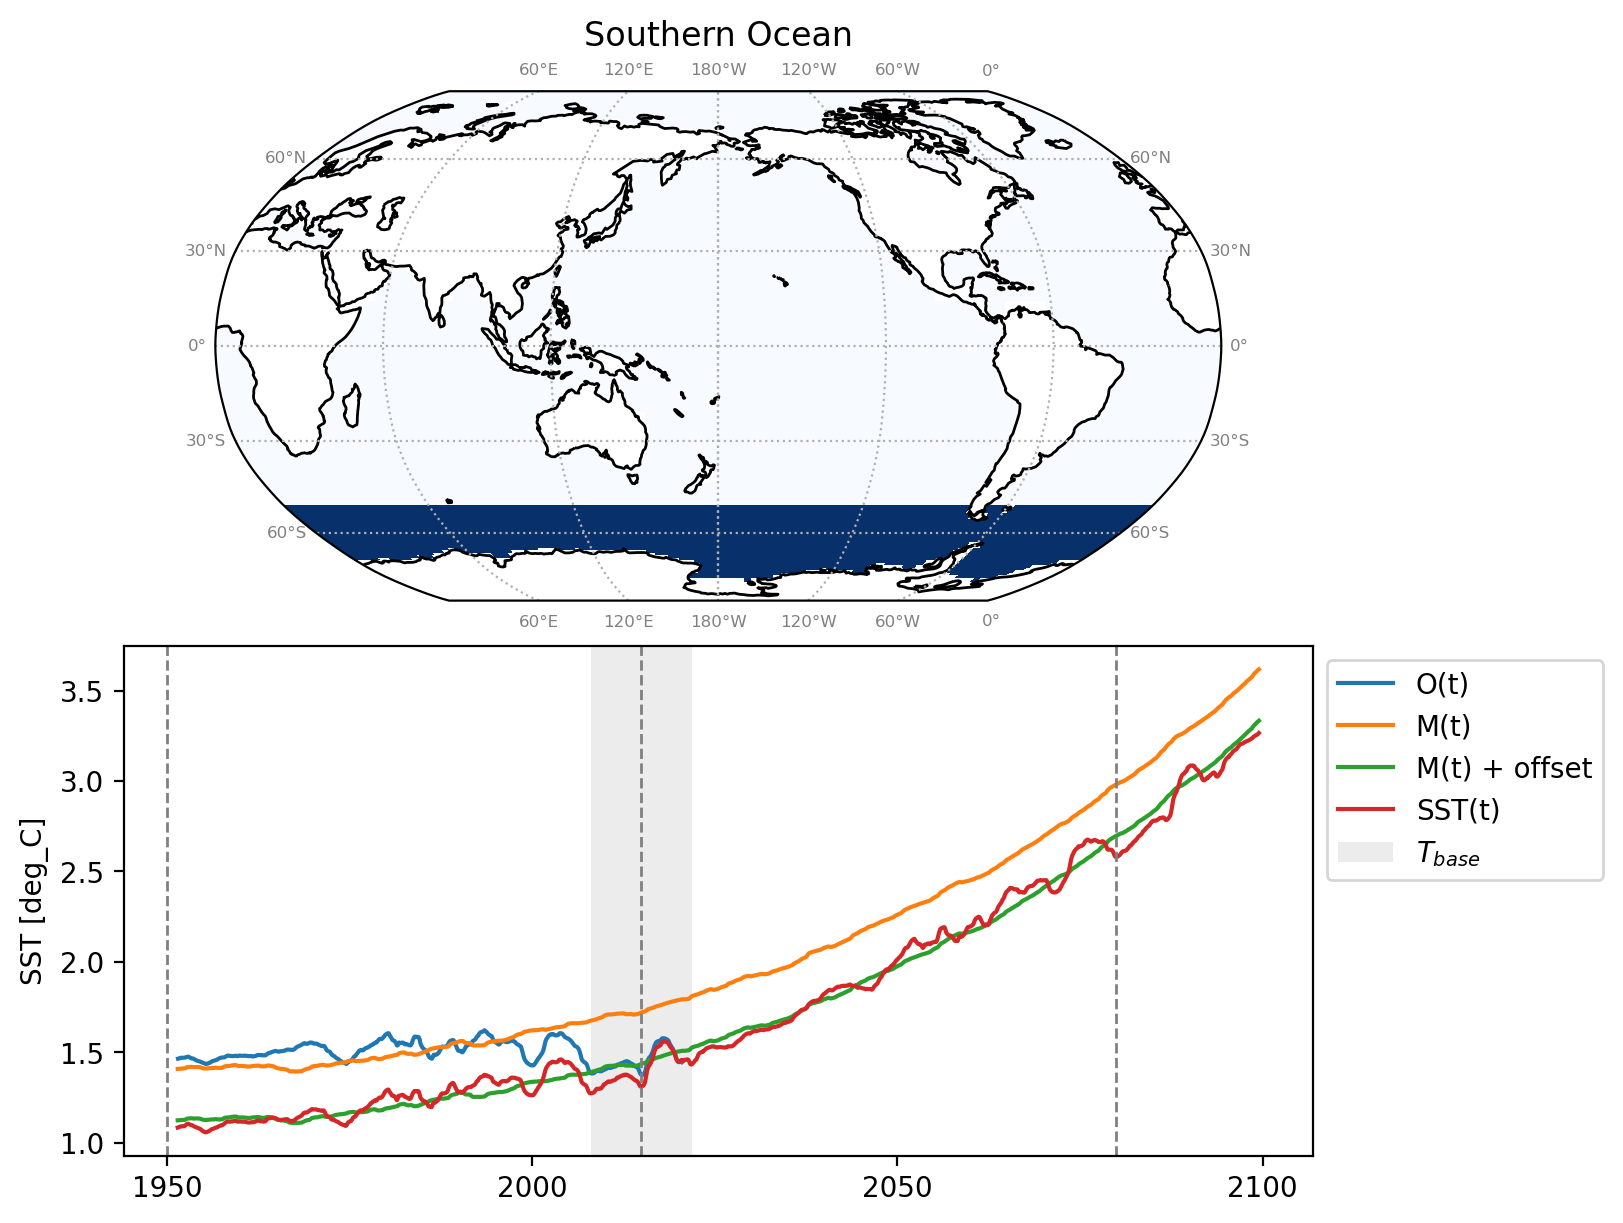

In [ ]:
fig = plt.figure(dpi=200, figsize=(8, 6), layout='constrained')

axm = fig.add_subplot(2, 1, 1, projection=ccrs.Robinson(central_longitude=-180))
axt = fig.add_subplot(2, 1, 2)

sop.plot(
    ax=axm,
    cmap='Blues',
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    # cbar_kwargs={'fraction': 0.03}
 )
# axm.set_extent([-178, 178, -90, 90], crs=ccrs.PlateCarree())
axm.coastlines()
gl = axm.gridlines(lw=0.8, ls=':', draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_left = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 6, 'color': 'gray'}
gl.ylabel_style = {'size': 6, 'color': 'gray'}
axm.set_title('Southern Ocean')

obs.where(sop).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='O(t)')
lens.where(sop).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t)')
lens_offset.where(sop).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t) + offset')
sst.where(sop).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='SST(t)')

axt.axvspan(
    cftime.DatetimeGregorian(2008, 1, 1),
    cftime.DatetimeGregorian(2021, 12, 1),
    color='gray', alpha=0.15, lw=0, label='$T_{base}$'
)
axt.axvline(cftime.DatetimeGregorian(1950, 1, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014+65, 12, 1), color='gray', lw=1, ls='--')

axt.set_xlabel('')
axt.legend(loc='upper left', bbox_to_anchor=[1, 1])
axt.set_title('')
axt.set_ylabel('SST [deg_C]')

## Southern Ocean patch

In [153]:
lat_bnds = [-90, -50]
lon_bnds = [0, 360]

so = obs.isel(time=0)
so = ((so.lat >= lat_bnds[0]) & (so.lat < lat_bnds[1]) & (so.lon >= lon_bnds[0]) & (so.lon < lon_bnds[1]))
so = so.where(om)

Text(0, 0.5, 'SST [deg_C]')

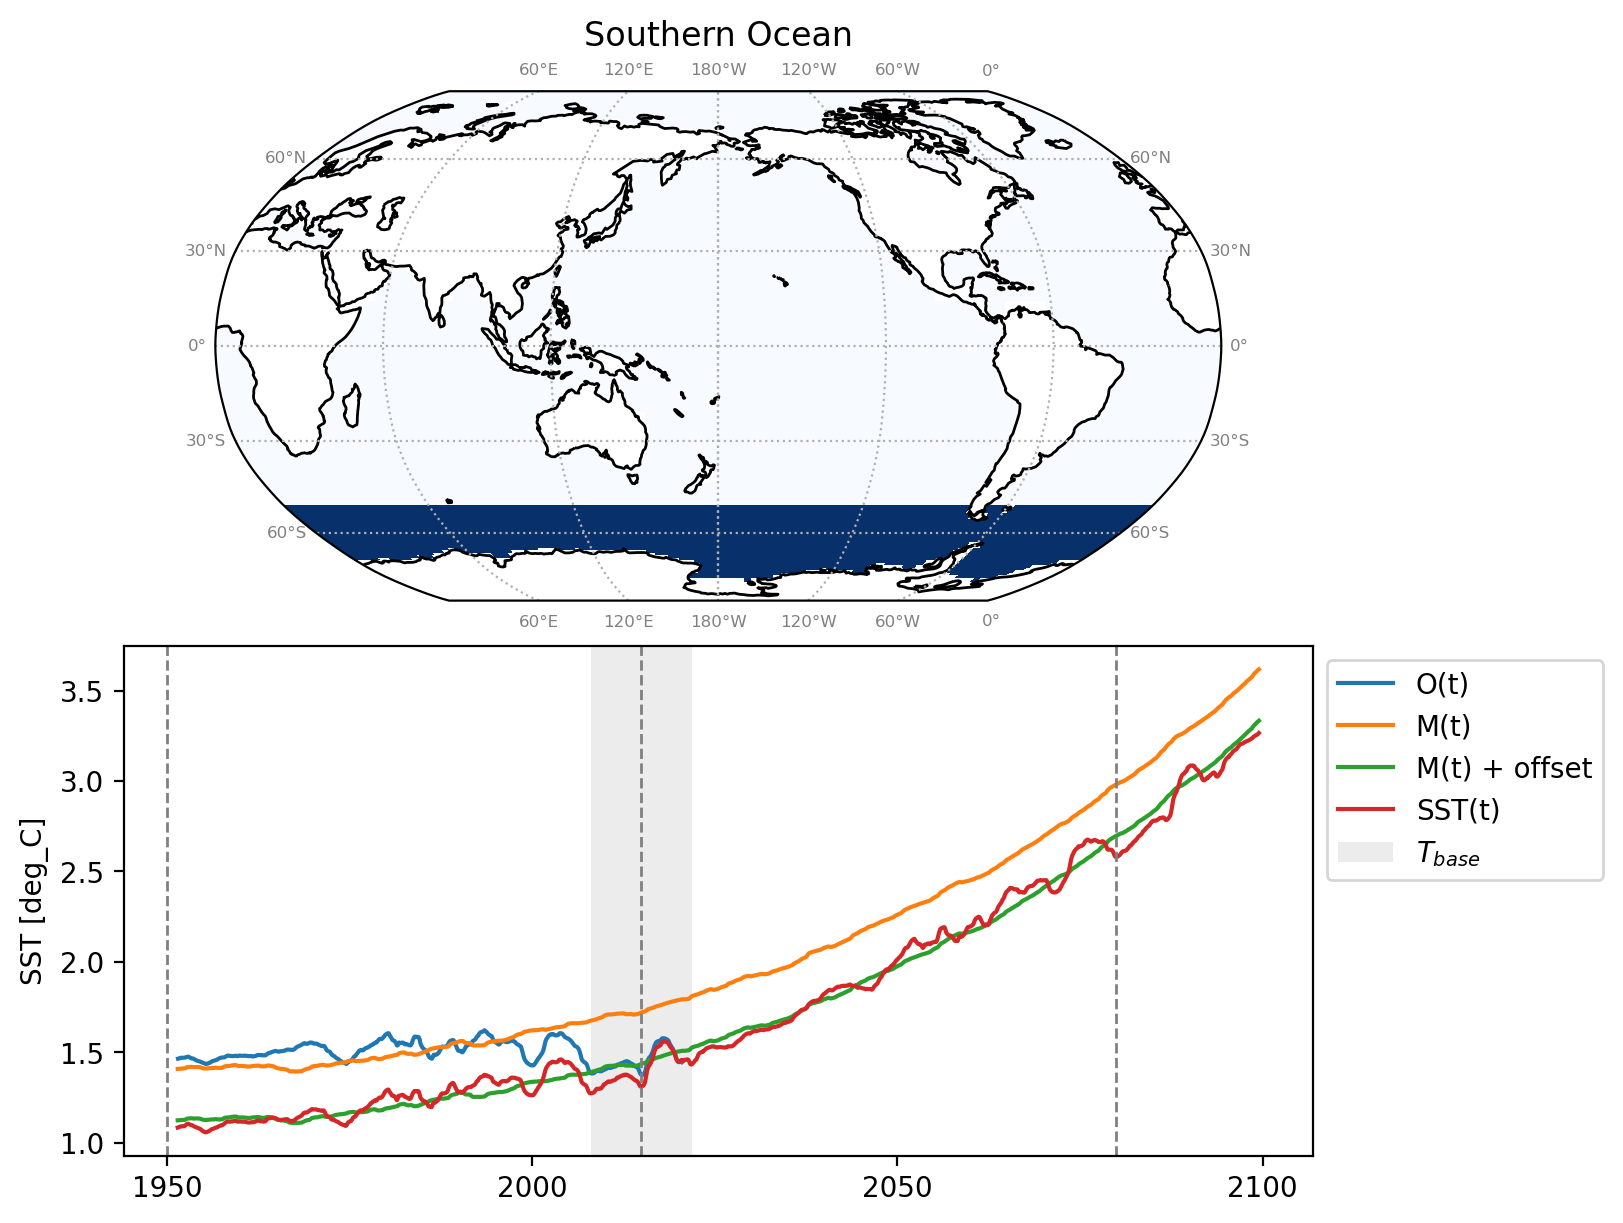

In [154]:
fig = plt.figure(dpi=200, figsize=(8, 6), layout='constrained')

axm = fig.add_subplot(2, 1, 1, projection=ccrs.Robinson(central_longitude=-180))
axt = fig.add_subplot(2, 1, 2)

so.plot(
    ax=axm,
    cmap='Blues',
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    # cbar_kwargs={'fraction': 0.03}
 )
# axm.set_extent([-178, 178, -90, 90], crs=ccrs.PlateCarree())
axm.coastlines()
gl = axm.gridlines(lw=0.8, ls=':', draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_left = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 6, 'color': 'gray'}
gl.ylabel_style = {'size': 6, 'color': 'gray'}
axm.set_title('Southern Ocean')

obs.where(so).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='O(t)')
lens.where(so).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t)')
lens_offset.where(so).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='M(t) + offset')
sst.where(so).weighted(deg1_oa).mean(dim=['lat', 'lon']).rolling(time=36, center=True).mean().plot(ax=axt, ls='-', label='SST(t)')

axt.axvspan(
    cftime.DatetimeGregorian(2008, 1, 1),
    cftime.DatetimeGregorian(2021, 12, 1),
    color='gray', alpha=0.15, lw=0, label='$T_{base}$'
)
axt.axvline(cftime.DatetimeGregorian(1950, 1, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
axt.axvline(cftime.DatetimeGregorian(2014+65, 12, 1), color='gray', lw=1, ls='--')

axt.set_xlabel('')
axt.legend(loc='upper left', bbox_to_anchor=[1, 1])
axt.set_title('')
axt.set_ylabel('SST [deg_C]')

# sea ice

## load Had sea ice

In [24]:
ds = xr.open_dataset('/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1/AREA/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.AREA.195001-195912.nc')
area = ds.AREA.isel(time=0)

ds = xr.open_dataset('/glade/campaign/collections/gdex/data/d651056/CESM2-LE/lnd/proc/tseries/month_1/GPP/b.e21.BHISTcmip6.f09_g17.LE2-1301.006.clm2.h2.GPP.195001-195912.nc')
ds = ds.reindex_like(area, tolerance=1e-3, method='nearest')
a = (ds.area * 1e6).assign_attrs({'units': 'm2'})
lf = ds.landfrac
la = a * lf
lm = ~np.isnan(la)
om = ~lm
oa = area.where(om)

In [156]:
hadbc = xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/atm/cam/sst/sst_HadOIBl_bc_0.9x1.25_1850_2022_c241003.nc')
obs = hadbc.ice_cov_prediddle.sel(time=slice('1950-01', '2021-12'))

obsm = split_years_months(obs)
obsm = obsm.chunk({'lat': 192, 'lon': 288, 'month': 1, 'year': -1}).persist()
tyears = obsm.year
coeffs = obsm.polyfit(dim='year', deg=1, skipna=True).polyfit_coefficients
trend = coeffs.sel(degree=1) # per year

obsm_dt = obsm - trend * (tyears - tyears[0])
obsm_dt_mean = obsm_dt.mean(dim='year')
obsm_dtdm = obsm_dt - obsm_dt_mean

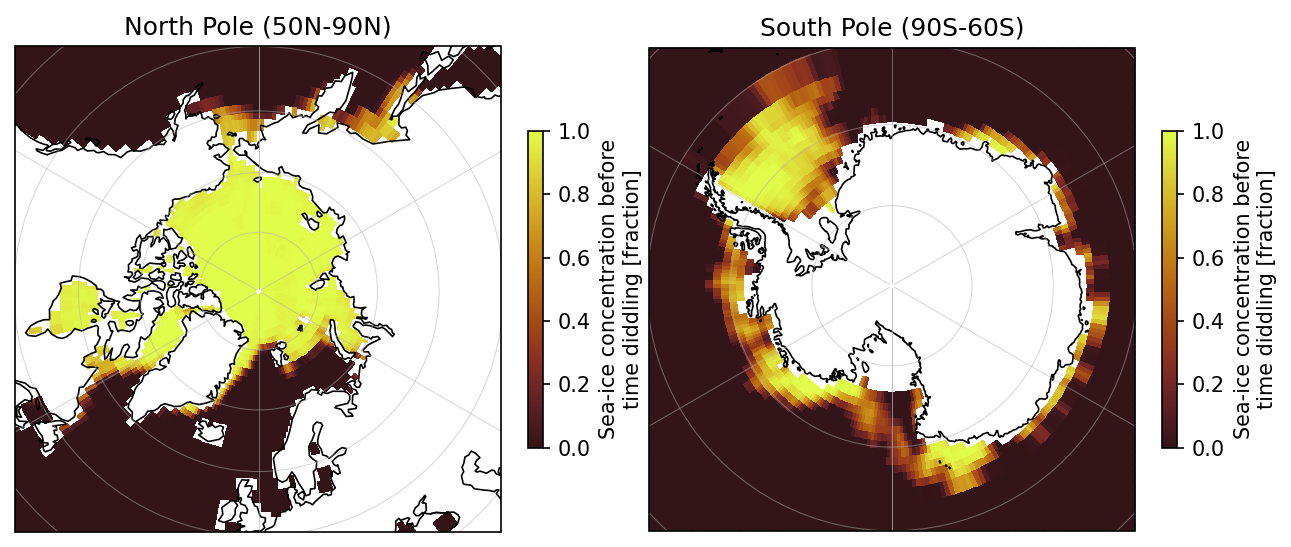

In [157]:
fig = plt.figure(figsize=(10, 6), dpi=150)
ax_n = fig.add_subplot(1, 2, 1, projection=ccrs.NorthPolarStereo())
ax_s = fig.add_subplot(1, 2, 2, projection=ccrs.SouthPolarStereo())

icy = cmo.solar
# icy.set_bad('mistyrose')
icy.set_bad((0, 0, 0, 0))

obs.isel(time=12*45).where(om).plot(
    ax=ax_n,
    transform=ccrs.PlateCarree(),
    cmap=icy,
    add_colorbar=True,
    cbar_kwargs={'fraction': 0.03}
 )
ax_n.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
ax_n.set_title('North Pole (50N-90N)')

obs.isel(time=12*45).where(om).plot(
    ax=ax_s,
    transform=ccrs.PlateCarree(),
    cmap=icy,
    add_colorbar=True,
    cbar_kwargs={'fraction': 0.03}
 )
ax_s.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
ax_s.set_title('South Pole (90S-60S)')

for a in [ax_n, ax_s]:
    # a.add_feature(
    #     cfeature.LAND,
    #     facecolor="lightgray",
    #     edgecolor="none",
    #     zorder=10
    # )
    a.coastlines(linewidth=0.8, color='black')
    a.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5)

## load LENS2 and compute ensemble mean

In [42]:
xr.set_options(use_new_combine_kwarg_defaults=True)

v = 'ICEFRAC'
bb = 'cmip6'

lens_dir = '/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1'
lens_starts = ['1001', '1021', '1041', '1061', '1081', '1101', '1121', '1141', '1161', '1181', '1231', '1251', '1281', '1301']

lens = []
mem = []
for im, yr in enumerate(lens_starts):
    print(f' - {yr}')
    if int(yr) < 1200:
        ts = []
        for cs in ['BHIST', 'BSSP370']:
            ds = xr.open_mfdataset(f'{lens_dir}/{v}/b.e21.{cs}{bb}.f09_g17.LE2-{yr}.{str(im+1).zfill(3)}.cam.h0.{v}.*.nc').sel(time=slice('1950-01', None))
            ts.append(ds)
        ts = xr.concat(ts, dim='time', data_vars=[v])
        ts = xclim.time_coord.shift_time(ts)
        lens.append(ts[v])
    else:
        for i in range(1, 11):
            print(str(i).zfill(3), end=' ')
            ts = []
            for cs in ['BHIST', 'BSSP370']:
                ds = xr.open_mfdataset(f'{lens_dir}/{v}/b.e21.{cs}{bb}.f09_g17.LE2-{yr}.{str(i).zfill(3)}.cam.h0.{v}.*.nc').sel(time=slice('1950-01', None))
                ts.append(ds)
            ts = xr.concat(ts, dim='time', data_vars=[v])
            ts = xclim.time_coord.shift_time(ts)
            lens.append(ts[v])
        print()
        

lens = xr.concat(lens, dim='ens').reindex(lat=obs.lat, lon=obs.lon, method='nearest', tolerance=1e-3)

 - 1001
 - 1021
 - 1041
 - 1061
 - 1081
 - 1101
 - 1121
 - 1141
 - 1161
 - 1181
 - 1231
001 002 003 004 005 006 007 008 009 010 
 - 1251
001 002 003 004 005 006 007 008 009 010 
 - 1281
001 002 003 004 005 006 007 008 009 010 
 - 1301
001 002 003 004 005 006 007 008 009 010 


In [43]:
lens

<xarray.DataArray 'ICEFRAC' (ens: 50, time: 1813, lat: 192, lon: 288)> Size: 20GB
dask.array<concatenate, shape=(50, 1813, 192, 288), dtype=float32, chunksize=(1, 1, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 15kB 1950-01-01 00:00:00 ... 2101-01-01 00:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Dimensions without coordinates: ens
Attributes:
    units:         fraction
    long_name:     Fraction of sfc area covered by sea-ice
    cell_methods:  time: mean

In [44]:
lens = lens.assign_coords(ens=('ens', np.arange(1, 51)))

lens = dask.optimize(lens)[0]
lensm_ens = lens.mean(dim='ens').rechunk(time=-1)

lensm_ens.to_netcdf(f'/glade/campaign/univ/uwas0155/ppe/future/sst/b.e21.cmip6.f09_g17.LE2-ens-mean.cam.h0.{v}.nc')

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 48.26 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


## open LENS2 ensemble mean

In [158]:
lens = xr.open_dataset('/glade/campaign/univ/uwas0155/ppe/future/sst/b.e21.cmip6.f09_g17.LE2-ens-mean.cam.h0.ICEFRAC.nc').ICEFRAC.sel(time=slice(None, '2100-12'))

In [159]:
lensm = split_years_months(lens)
lensm = lensm.chunk({'lat': -1, 'lon': -1, 'year': 152, 'month': 1}).persist()

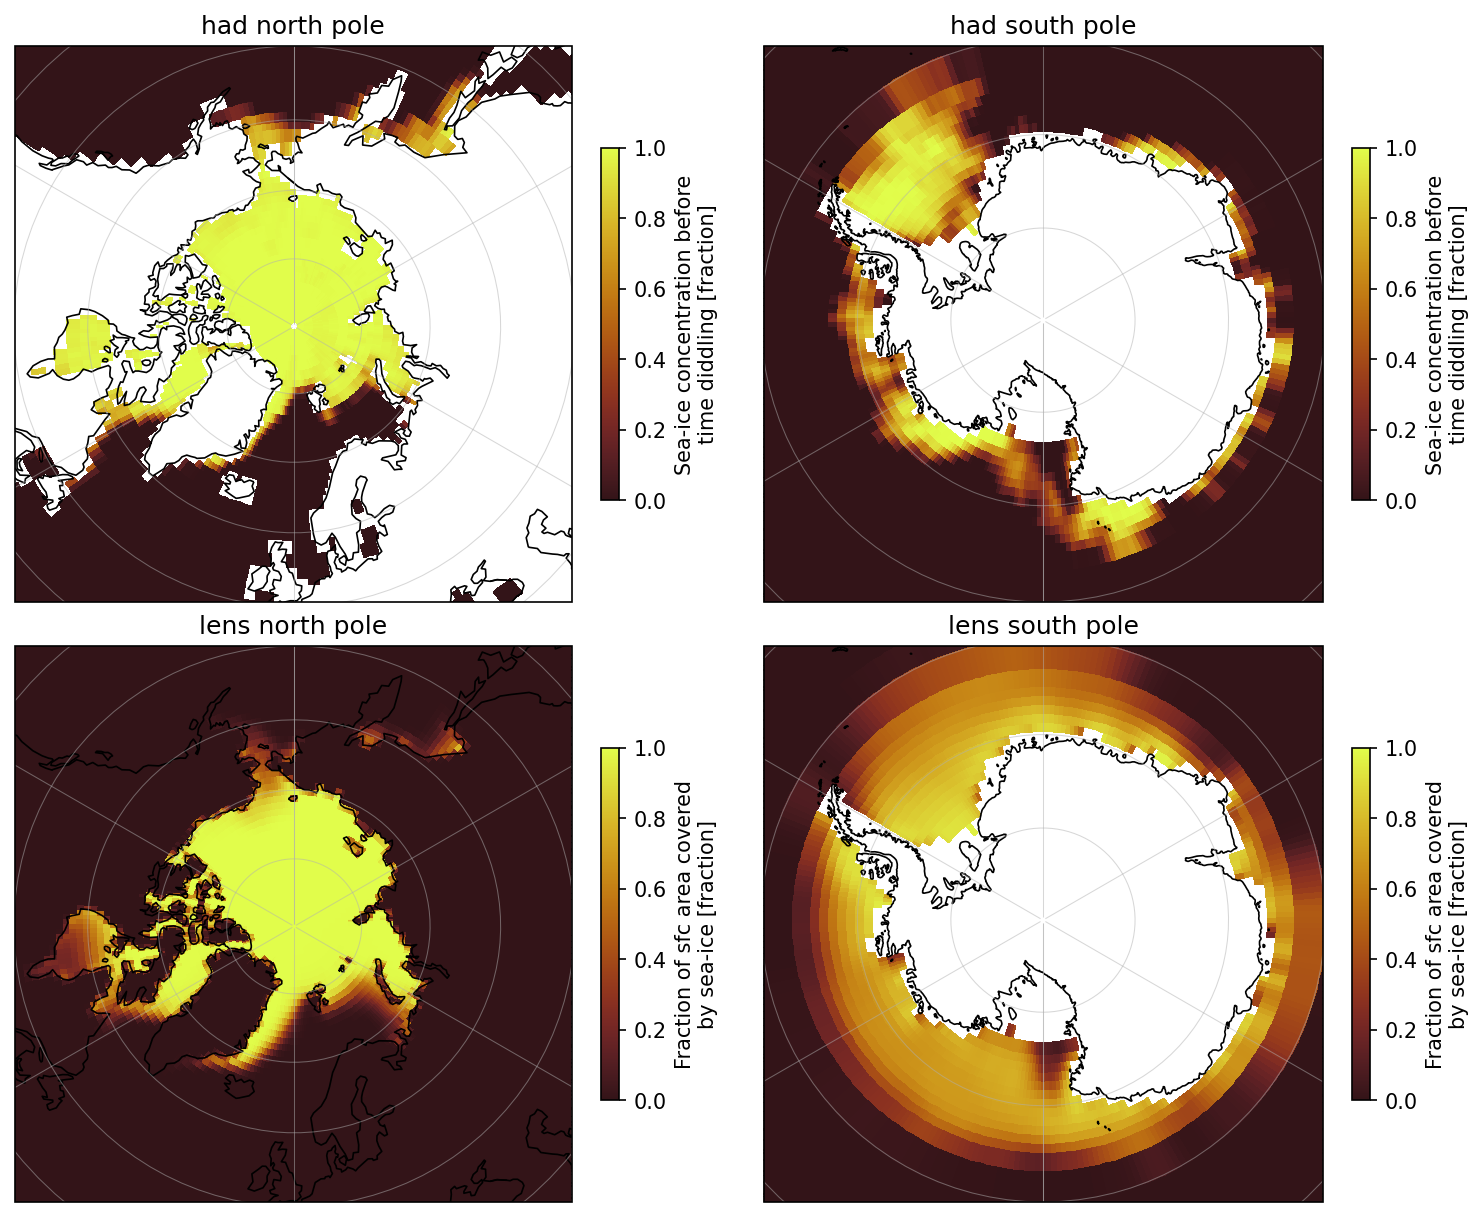

In [160]:
fig = plt.figure(figsize=(10, 8), dpi=150, layout='constrained')
ax_n = [
    fig.add_subplot(2, 2, 1, projection=ccrs.NorthPolarStereo()),
    fig.add_subplot(2, 2, 3, projection=ccrs.NorthPolarStereo()),
]
ax_s = [
    fig.add_subplot(2, 2, 2, projection=ccrs.SouthPolarStereo()),
    fig.add_subplot(2, 2, 4, projection=ccrs.SouthPolarStereo()),
]

cmap = cmo.solar

obs.isel(time=12*45).where(om).plot(
    ax=ax_n[0],
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    add_colorbar=True,
    cbar_kwargs={'fraction': 0.03},
    vmin=0, vmax=1,
)

obs.isel(time=12*45).where(om).plot(
    ax=ax_s[0],
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    add_colorbar=True,
    cbar_kwargs={'fraction': 0.03},
    vmin=0, vmax=1,
)


lens.isel(time=12*45).plot(
    ax=ax_n[1],
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    add_colorbar=True,
    cbar_kwargs={'fraction': 0.03},
    vmin=0, vmax=1,
)

lens.isel(time=12*45).where(om).plot(
    ax=ax_s[1],
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    add_colorbar=True,
    cbar_kwargs={'fraction': 0.03},
    vmin=0, vmax=1,
)

for ax in ax_n:
    ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
    ax.set_title('')

ax_n[0].set_title('had north pole')
ax_n[1].set_title('lens north pole')

for ax in ax_s:
    ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
    ax.set_title('')

ax_s[0].set_title('had south pole')
ax_s[1].set_title('lens south pole')

for ax in ax_n + ax_s:
    # ax.add_feature(
    #     cfeature.LAND,
    #     facecolor="lightgray",
    #     edgecolor="none",
    #     zorder=10
    # )
    ax.coastlines(linewidth=0.8, color='black')
    ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5)

## sea ice regions

region_ids: {'gin': 1, 'barents': 2, 'kara': 3, 'laptev': 4, 'eastsib': 5, 'chukchi': 6, 'beaufort': 7, 'okhotsk': 8, 'baffin': 9, 'central': 10}
min/max label: 0 10


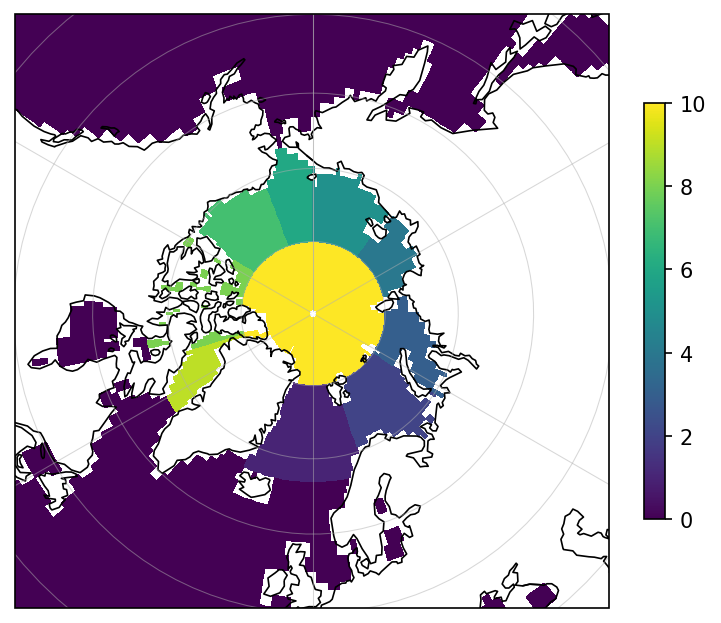

In [161]:
# https://www.gfdl.noaa.gov/arctic-sea-ice-predictions/
lat_bnds = [67, 80]
cice_regions = {
    'gin': [335, 18],
    'barents': [18, 57],
    'kara': [57, 103],
    'laptev': [103, 143],
    'eastsib': [143, 180],
    'chukchi': [180, 200],
    'beaufort': [200, 235],
    'okhotsk': [235, 287],
    'baffin': [287, 320],
}

cice_iregmask = xr.zeros_like(obs.isel(time=0), dtype=np.int16)
region_ids = {}

for ireg, (name, lon_bnds) in enumerate(cice_regions.items(), start=1):
    if lon_bnds[0] > lon_bnds[1]:
        in_region = (
            (obs.lat > lat_bnds[0])
            & (obs.lat <= lat_bnds[1])
            & ((obs.lon > lon_bnds[0]) | (obs.lon <= lon_bnds[1]))
        )
    else:
        in_region = (
            (obs.lat > lat_bnds[0])
            & (obs.lat <= lat_bnds[1])
            & (obs.lon > lon_bnds[0])
            & (obs.lon <= lon_bnds[1])
        )

    # Assign region ID where condition is true; 0 remains outside all regions.
    cice_iregmask = xr.where(in_region, ireg, cice_iregmask)
    region_ids[name] = ireg

ireg += 1
in_region = (
    (obs.lat > lat_bnds[1])
    & (obs.lon >= 0)
    & (obs.lon < 360)
)
cice_iregmask = xr.where(in_region, ireg , cice_iregmask)
region_ids['central'] = ireg 

# ireg += 1
# in_region = (
#     (obs.lat > lat_bnds[0])
#     & (obs.lon >= 0)
#     & (obs.lon < 360)
# )
# cice_iregmask = xr.where(in_region, ireg, cice_iregmask)
# region_ids['central'] = ireg

print('region_ids:', region_ids)
print('min/max label:', int(cice_iregmask.min().item()), int(cice_iregmask.max().item()))

fig = plt.figure(figsize=(10, 8), dpi=150, layout='constrained')
ax = fig.add_subplot(2, 2, 1, projection=ccrs.NorthPolarStereo())

cice_iregmask.where(om).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    add_colorbar=True,
    cbar_kwargs={'fraction': 0.03},
)

ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
ax.set_title('')
ax.coastlines(linewidth=0.8, color='black')
ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5)

## compute terms

In [162]:
base_tperiod = [2007, 2021]

In [163]:
# Rebuild fresh graphs here to avoid stale/missing dask dependencies.
obsm = split_years_months(obs).chunk({'lat': 192, 'lon': 288, 'month': 1, 'year': -1})

# Recompute observational detrended monthly anomalies used later in the stack term.
tyears = obsm.year
coeffs = obsm.polyfit(dim='year', deg=1, skipna=True).polyfit_coefficients
trend = coeffs.sel(degree=1)
obsm_dt = obsm - trend * (tyears - tyears[0])
obsm_dt_mean = obsm_dt.mean(dim='year')
obsm_dtdm = obsm_dt - obsm_dt_mean

lensm = split_years_months(lens).chunk({'lat': 192, 'lon': 288, 'month': 1, 'year': -1})

obsm_base = obsm.sel(year=slice(base_tperiod[0], base_tperiod[1])).mean(dim='year').compute()
lensm_base = lensm.sel(year=slice(base_tperiod[0], base_tperiod[1])).mean(dim='year').compute()

In [164]:
offset = (obsm_base - lensm_base).compute()
lensm_offset = (lensm + offset).clip(min=0, max=1)

In [165]:
obs_yrs = len(obsm_dtdm.year)
ens_yrs = len(lensm.year)

n_stack = ens_yrs // obs_yrs + 1

obsm_dtdm_stack = (
    xr.concat(n_stack * [obsm_dtdm], dim='year')
    .isel(year=slice(0, ens_yrs))
    .assign_coords(year=lensm.year)
)

# Force a consistent datetime coord source to avoid dask dependency issues
# when xarray merges coords during arithmetic.
obsm_dtdm_stack = obsm_dtdm_stack.drop_vars('datetime').assign_coords(datetime=lensm.datetime)

assert lensm.shape == obsm_dtdm_stack.shape

In [166]:
# Drop datetime before arithmetic and add back from lensm to avoid coord-merge graph conflicts.
lensm_calc = lensm.drop_vars('datetime')
stack_calc = obsm_dtdm_stack.drop_vars('datetime')

sicem = (lensm_calc + offset + stack_calc).clip(min=0, max=1).assign_coords(datetime=lensm.datetime)

In [167]:
lensm_offset = lensm_offset.compute()
sicem = sicem.compute()

In [168]:
lens_offset = combine_years_months(lensm_offset.assign_coords(datetime=lensm.datetime))
sice = combine_years_months(sicem.assign_coords(datetime=lensm.datetime))

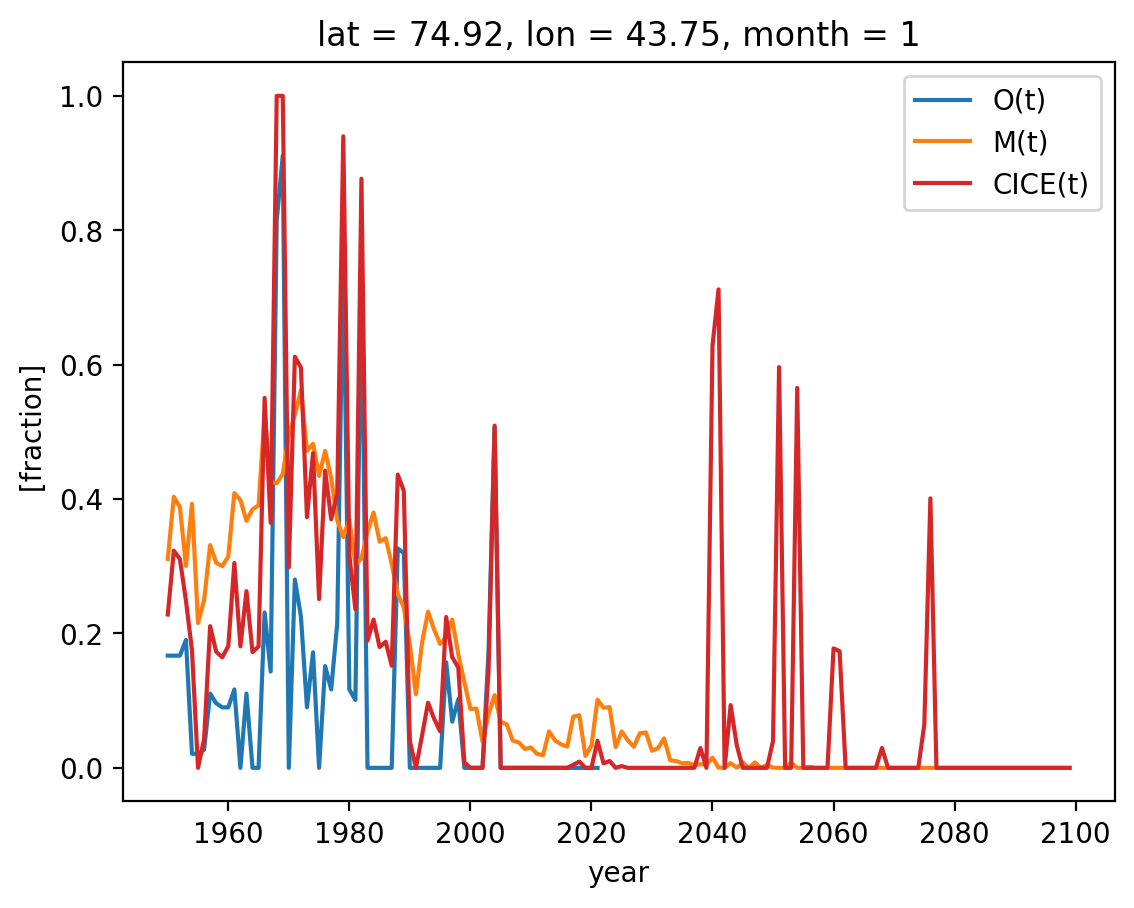

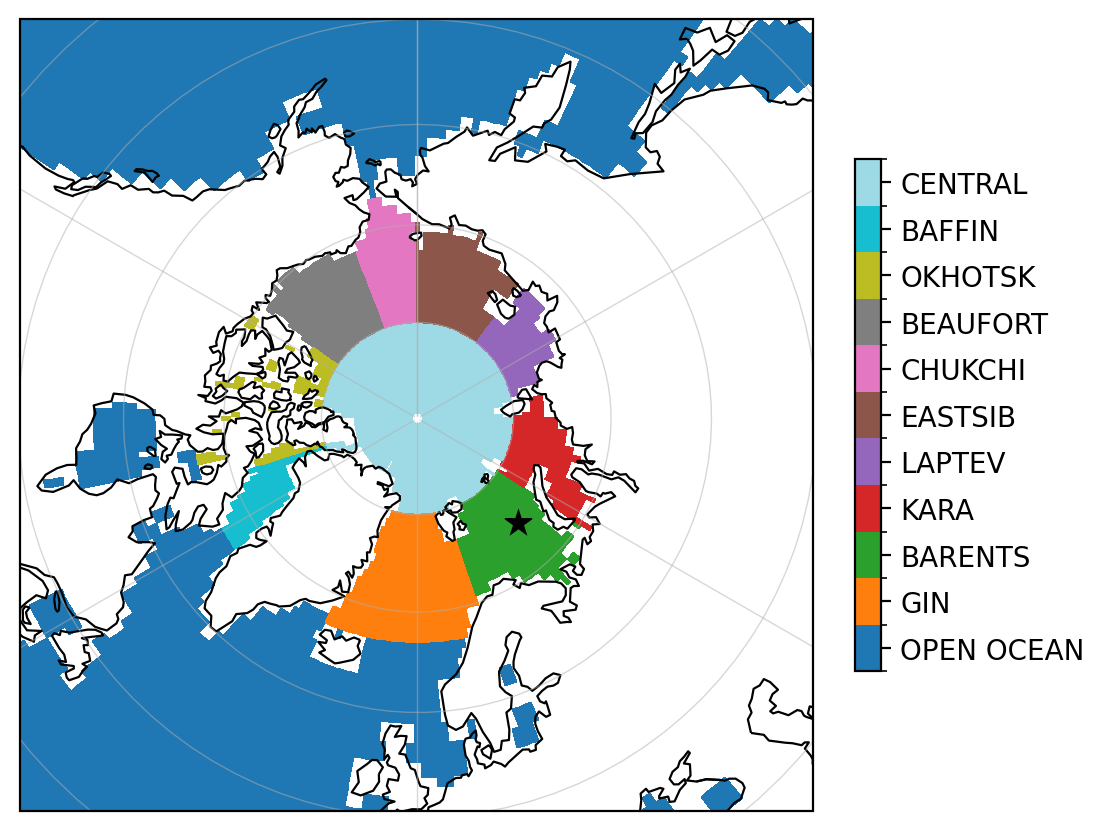

In [185]:
ilat = 175
ilon = 35
imon = 0

plt.figure(dpi=200)
obsm.isel(lat=ilat, lon=ilon, month=imon).plot(label='O(t)')
lensm.isel(lat=ilat, lon=ilon, month=imon, year=slice(0, 150)).plot(label='M(t)')
sicem.isel(lat=ilat, lon=ilon, month=imon, year=slice(0, 150)).plot(c='tab:red', label='CICE(t)')
plt.legend()
plt.title(f'lat = {obsm.lat.isel(lat=ilat):0.2f}, lon = {obsm.lon.isel(lon=ilon):0.2f}, month = {imon+1}')




fig = plt.figure(figsize=(10, 8), dpi=200, layout='constrained')
ax = fig.add_subplot(2, 2, 1, projection=ccrs.NorthPolarStereo())

# Build integer->name lookup from region_ids for labeled colorbar ticks.
id_to_name = {0: 'open ocean'}
id_to_name.update({idx: name for name, idx in region_ids.items()})
labels = sorted(id_to_name.keys())
nlab = len(labels)

# Discrete colormap with one color per integer label, including 0 for open ocean.
cmap = plt.get_cmap('tab20', nlab)
norm = mcolors.BoundaryNorm(np.arange(-0.5, labels[-1] + 1.5, 1), cmap.N)

p = cice_iregmask.where(om).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={'fraction': 0.03, 'ticks': labels},
)

ax.scatter(obsm.lon.isel(lon=ilon), obsm.lat.isel(lat=ilat), s=120, marker='*', color='k', linewidth=0, transform=ccrs.PlateCarree())

# Replace numeric ticks with region names.
cbar = p.colorbar
cbar.set_ticklabels([id_to_name[i].upper() for i in labels])

ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
ax.set_title('')
ax.coastlines(linewidth=0.8, color='black')
ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5)

In [251]:
region_ids

{'gin': 1,
 'barents': 2,
 'kara': 3,
 'laptev': 4,
 'eastsib': 5,
 'chukchi': 6,
 'beaufort': 7,
 'okhotsk': 8,
 'baffin': 9,
 'central': 10}

Text(0.5, 0.98, 'mean sea ice fraction for month = 1')

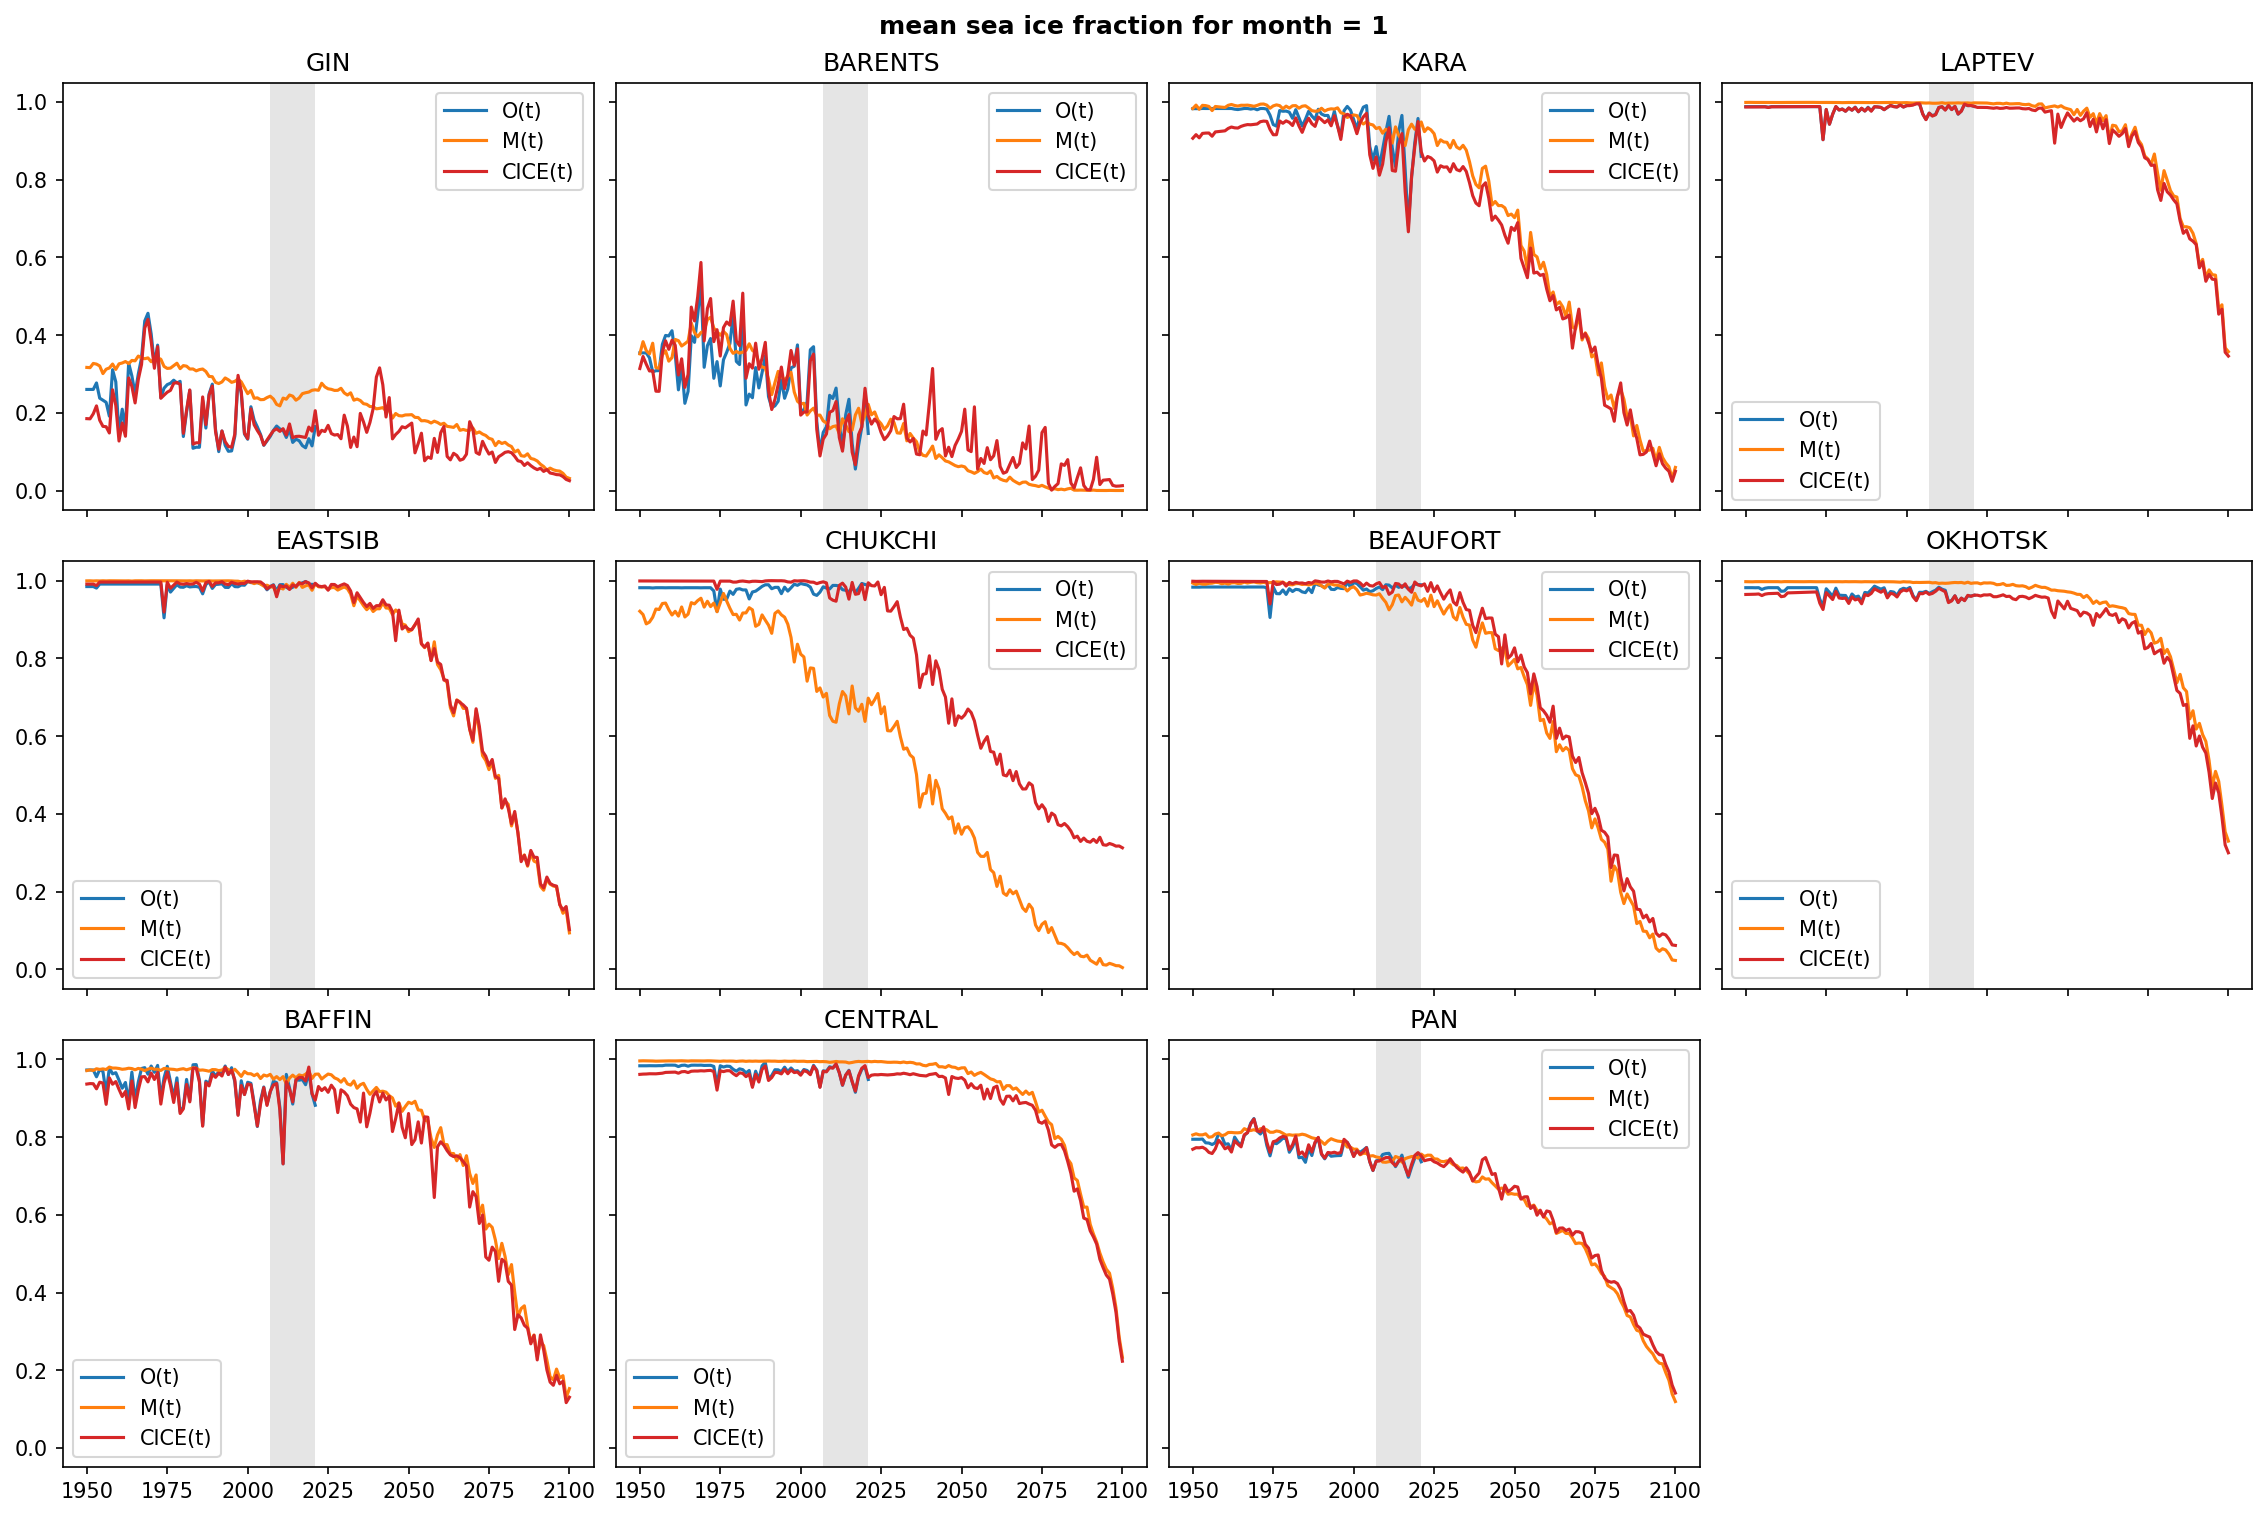

In [184]:
im = 0
yrs = slice(1950, 2100)

fig, axs = plt.subplots(3, 4, figsize=(15, 10), sharex=True, sharey=True, layout='constrained', dpi=150)
ax = axs.flatten()

for name, i in region_ids.items():
    obsm.isel(month=im).sel(year=yrs).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:blue', label='O(t)')
    lensm.isel(month=im).sel(year=yrs).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:orange', label='M(t)')
    sicem.isel(month=im).sel(year=yrs).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:red', label='CICE(t)')
    ax[i-1].set_xlabel('')
    ax[i-1].set_ylabel('')
    ax[i-1].legend()
    ax[i-1].set_title(name.upper())

i += 1
obsm.isel(month=im).sel(year=yrs).where(obsm.lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:blue', label='O(t)')
lensm.isel(month=im).sel(year=yrs).where(lensm.lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:orange', label='M(t)')
sicem.isel(month=im).sel(year=yrs).where(sicem.lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:red', label='CICE(t)')
ax[i-1].set_xlabel('')
ax[i-1].set_ylabel('')
ax[i-1].legend()
ax[i-1].set_title('PAN')

ax[-1].remove()

for a in ax:
    a.axvspan(
        base_tperiod[0],
        base_tperiod[1],
        color='gray',
        alpha=0.2,
        linewidth=0,
    )

plt.suptitle(f'mean sea ice fraction for month = {im+1}', fontweight='bold')

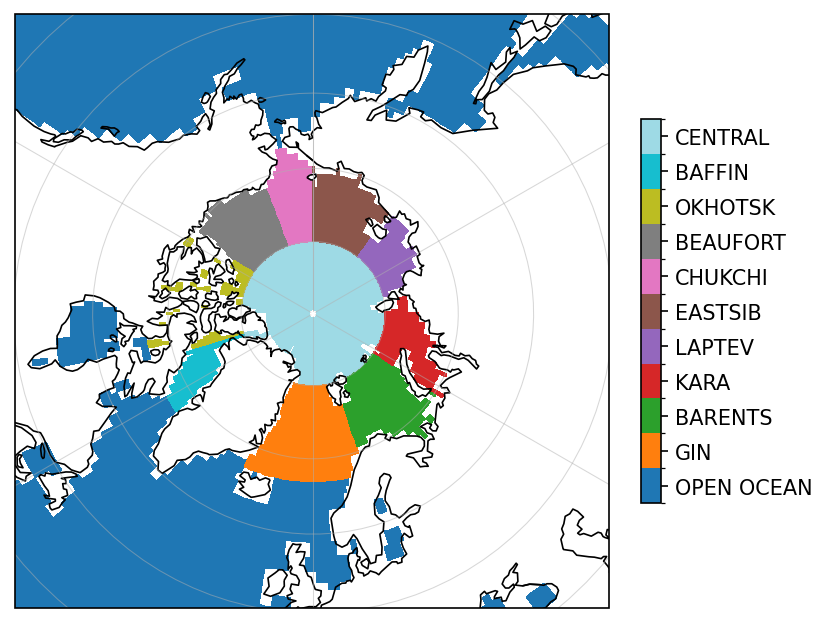

In [175]:
fig = plt.figure(figsize=(10, 8), dpi=150, layout='constrained')
ax = fig.add_subplot(2, 2, 1, projection=ccrs.NorthPolarStereo())

# Build integer->name lookup from region_ids for labeled colorbar ticks.
id_to_name = {0: 'open ocean'}
id_to_name.update({idx: name for name, idx in region_ids.items()})
labels = sorted(id_to_name.keys())
nlab = len(labels)

# Discrete colormap with one color per integer label, including 0 for open ocean.
cmap = plt.get_cmap('tab20', nlab)
norm = mcolors.BoundaryNorm(np.arange(-0.5, labels[-1] + 1.5, 1), cmap.N)

p = cice_iregmask.where(om).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={'fraction': 0.03, 'ticks': labels},
)

# Replace numeric ticks with region names.
cbar = p.colorbar
cbar.set_ticklabels([id_to_name[i].upper() for i in labels])

ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
ax.set_title('')
ax.coastlines(linewidth=0.8, color='black')
ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5)